# Applying the pipeline to the Server Machine Dataset

This notebook runs the MahaKNN against the **Server Machine Dataset** (SMD),
released with the OmniAnomaly paper (Su et al., KDD 2019). SMD is five weeks of telemetry
from 28 machines in a large internet company, sampled once a minute.

**Detector A - pooled corpus.** One corpus of every dyadic interval of every training window,
whitened once by a single global `Sigma^-1/2`, searched by depth band. Scoring an interval is
one FAISS query. This is what `anomaly_detection_pooled` does and what the Snakemake workflow
runs today.

**Detector B - recomputed per interval.** For each candidate interval the search asks about,
the reference set is rebuilt from the training windows *restricted to that same interval*, and
the Mahalanobis metric is refitted to it. Every interval is therefore judged against a corpus
and a metric at its own scale. This is the toy notebook's `pysegments_anomaly_detector`
strategy, carried to real data.

Both are calibrated by one protocol, which is the second thing this notebook is about:

> **train** the metric on a fit set, **find the threshold** on a withheld set of known-normal
> data the metric never saw, then **fold the withheld data into the final reference set** so
> detection runs against every normal window available.


## 1. The data

SMD ships as four directories of plain text, one file per machine:

| directory | contents |
|---|---|
| `train/` | 38 comma-separated channels per row, no header, min-max scaled to [0, 1] |
| `test/` | same shape, same machine, the period immediately following |
| `test_label/` | one `0`/`1` per test row |
| `interpretation_label/` | `start-end:dim,dim,...` - which channels explain each anomaly |

Train and test are separate contiguous periods, with the training half declared anomaly-free.
That is exactly the corpus-of-normality assumption both detectors are built on, and the
labels mean that for the first time in this project the detector can actually be scored
rather than eyeballed.

The values arriving pre-scaled to [0, 1] is a convenience worth noting: the `normalise` stage
the Snakemake workflow still lacks was motivated by nyc_taxi, where raw counts near 1e4 both
dominated the time channel and cost about eleven significant digits when intervals were
composed through Chen's identity. Neither problem arises here.

In [1]:
import sys
import time
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iisignature
import faiss

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT / 'src'))

from anomalies_scale.create_corpus_merged import add_base_point, create_corpus_merged, load_stream
from anomalies_scale.anomaly_detection_pooled import (
    IntervalSigner, PooledCorpus, build_whitening, split_corpus, widest_first_segment)

SMD = PROJECT / 'OmniAnomaly-master' / 'ServerMachineDataset'
WORK = PROJECT / 'data' / 'smd'
WORK.mkdir(parents=True, exist_ok=True)

MACHINES = sorted(p.stem for p in (SMD / 'train').glob('*.txt'))
print('{0} machines: {1} ... {2}'.format(len(MACHINES), MACHINES[0], MACHINES[-1]))


def load_machine(name):
    """Return one machine's (train, test, labels).

    Labels align with `test` row for row; `train` is unlabelled and assumed anomaly-free,
    which is what makes it usable as a corpus of normality.
    """
    read = lambda kind: pd.read_csv(SMD / kind / (name + '.txt'), header=None)
    return read('train'), read('test'), read('test_label')[0].to_numpy().astype(bool)

28 machines: machine-1-1 ... machine-3-9


In [2]:
# Survey every machine. Reading all 28 training files takes about a minute; the constant
# channel count is the reason to do it, since those columns carry no signal but do enter
# the covariance as exactly-zero variance directions.
rows = []
for name in MACHINES:
    train, test, labels = load_machine(name)
    rows.append({
        'machine': name,
        'n_train': len(train), 'n_test': len(test),
        'n_constant': int((train.std().to_numpy() == 0).sum()),
        'anomaly_rate': round(float(labels.mean()), 4),
        'n_segments': int(np.diff(np.concatenate([[0], labels.astype(int), [0]])).clip(0).sum()),
    })

survey = pd.DataFrame(rows)
print(survey.to_string(index=False))
print('\ntotal rows: {0:,} train / {1:,} test'.format(
    survey['n_train'].sum(), survey['n_test'].sum()))
print('anomaly rate: min {0:.4f}, median {1:.4f}, max {2:.4f}'.format(
    survey['anomaly_rate'].min(), survey['anomaly_rate'].median(),
    survey['anomaly_rate'].max()))

     machine  n_train  n_test  n_constant  anomaly_rate  n_segments
 machine-1-1    28479   28479           8        0.0946           8
 machine-1-2    23694   23694           5        0.0229          10
 machine-1-3    23702   23703           4        0.0345          12
 machine-1-4    23706   23707           4        0.0304          12
 machine-1-5    23705   23706           8        0.0042           7
 machine-1-6    23688   23689           5        0.1565          30
 machine-1-7    23697   23697           4        0.1012          13
 machine-1-8    23698   23699           8        0.0322          20
 machine-2-1    23693   23694           5        0.0494          13
 machine-2-2    23699   23700           7        0.1195          11
 machine-2-3    23688   23689           7        0.0114          10
 machine-2-4    23689   23689           8        0.0715          20
 machine-2-5    23688   23689           7        0.0414          21
 machine-2-6    28743   28743           8       

Two things stand out. Every machine has between 2 and 10 **constant channels** - columns that
never move across the whole training period. They contribute nothing but a zero-variance
direction to the covariance, so they are dropped below. And the **anomaly rate varies by a
factor of 37** across machines, from 0.4% to 15.7%, which means any single global threshold
is going to suit some machines much better than others. Each machine gets its own reference
set and its own threshold here, which is the natural reading of the dataset anyway: these are
different machines running different workloads, not samples from one population.

### The same channels on different machines

SMD's 38 columns carry the same nominal meaning on every machine - they are the same
telemetry counters, min-max scaled the same way - so it is fair to ask whether one corpus of
normality could serve all 28 at once. That question is worth settling before the pipeline
commits to building 28 of them.

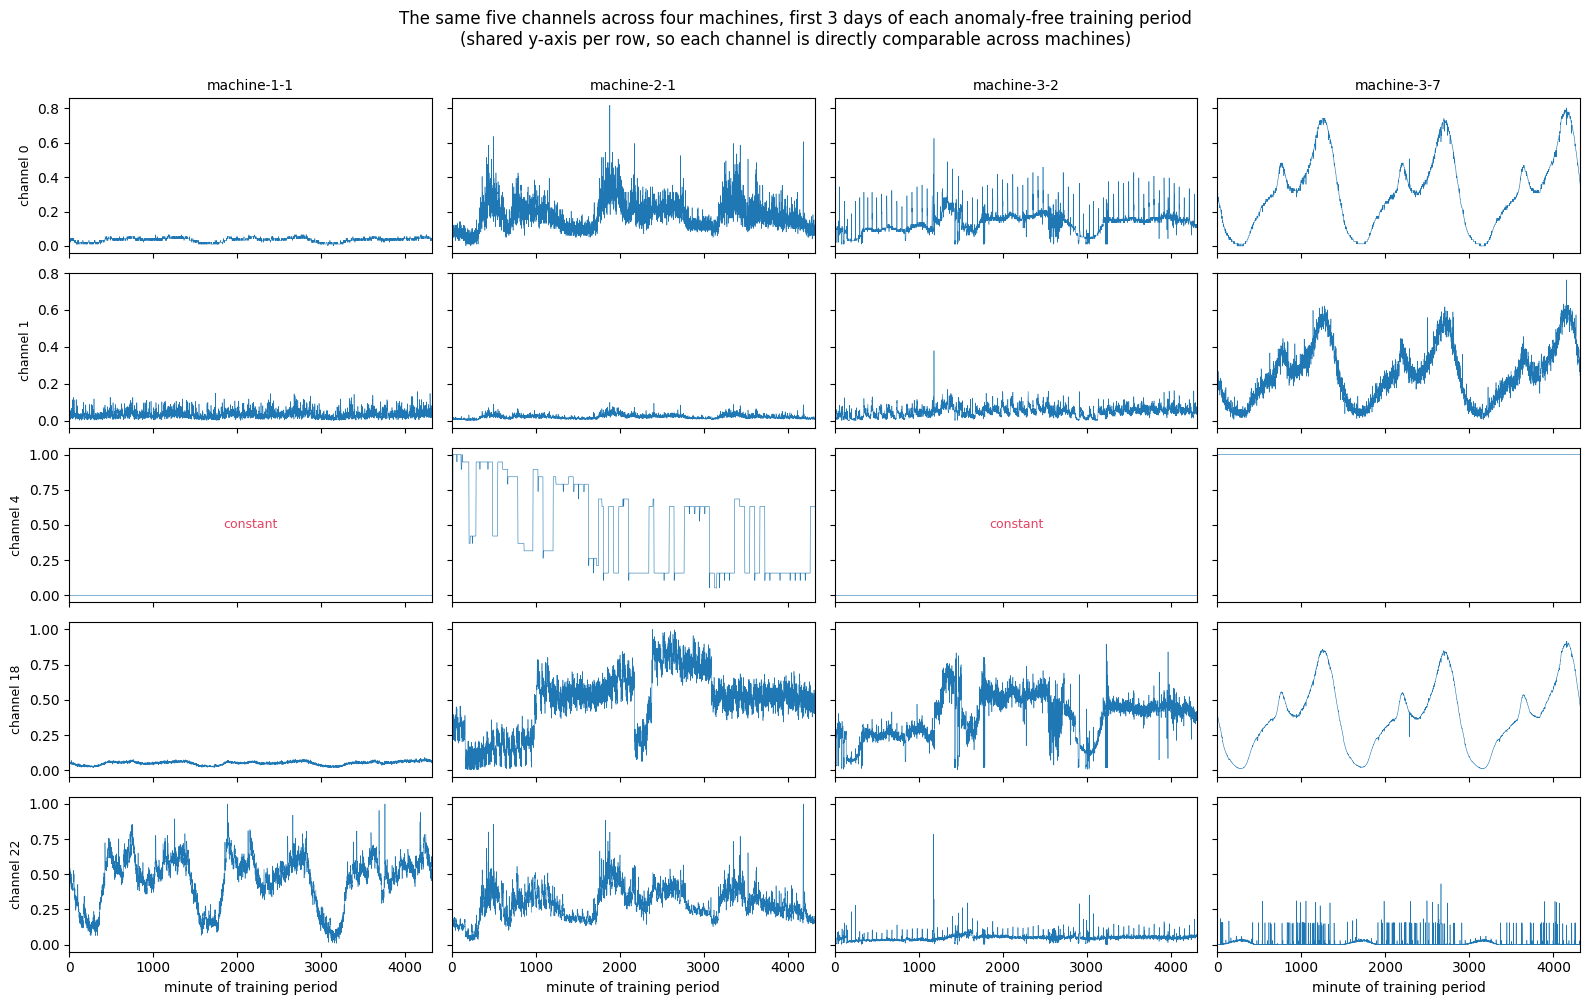

standard deviation of each channel, per machine:
         machine-1-1  machine-2-1  machine-3-2  machine-3-7
channel                                                    
0             0.0567       0.0898       0.1363       0.2486
1             0.0425       0.0119       0.0916       0.1748
4             0.0000       0.2570       0.0000       0.0115
18            0.0397       0.1944       0.1497       0.2618
22            0.2857       0.1195       0.0251       0.0289

ratio of largest to smallest non-zero std, per channel:
  channel  0:      4.4x
  channel  1:     14.7x
  channel  4:     22.3x   (2 machine(s) hold it constant)
  channel 18:      6.6x
  channel 22:     11.4x


In [3]:
# The same channels, on four different machines. SMD's 38 columns carry the same nominal
# meaning everywhere - they are the same telemetry counters - so it is fair to ask whether one
# corpus of normality could serve all 28 machines at once.
COMPARE_MACHINES = ['machine-1-1', 'machine-2-1', 'machine-3-2', 'machine-3-7']
COMPARE_CHANNELS = [0, 1, 4, 18, 22]
DAYS = 3                                     # SMD is sampled once a minute

fig, axes = plt.subplots(len(COMPARE_CHANNELS), len(COMPARE_MACHINES),
                         figsize=(16, 10), sharex=True, sharey='row')

deviations = {}
for column, name in enumerate(COMPARE_MACHINES):
    machine_train = load_machine(name)[0]
    deviations[name] = machine_train.std()

    for row, channel in enumerate(COMPARE_CHANNELS):
        ax = axes[row, column]
        series = machine_train[channel].to_numpy()[:DAYS * 24 * 60]
        ax.plot(series, lw=0.4, color='#1f77b4')
        ax.margins(x=0)

        if machine_train[channel].std() == 0:
            ax.text(0.5, 0.5, 'constant', transform=ax.transAxes, ha='center', va='center',
                    fontsize=9, color='crimson', alpha=0.8)
        if row == 0:
            ax.set_title(name, fontsize=10)
        if column == 0:
            ax.set_ylabel('channel {0}'.format(channel), fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel('minute of training period')

fig.suptitle('The same five channels across four machines, first {0} days of each '
             'anomaly-free training period\n(shared y-axis per row, so each channel is '
             'directly comparable across machines)'.format(DAYS), y=1.0)
plt.tight_layout()
plt.show()

spread = pd.DataFrame(deviations).loc[COMPARE_CHANNELS]
spread.index.name = 'channel'
print('standard deviation of each channel, per machine:')
print(spread.to_string(float_format=lambda v: '{0:.4f}'.format(v)))
print('\nratio of largest to smallest non-zero std, per channel:')
for channel in COMPARE_CHANNELS:
    values = spread.loc[channel]
    active = values[values > 0]
    zeros = int((values == 0).sum())
    note = '' if not zeros else '   ({0} machine(s) hold it constant)'.format(zeros)
    print('  channel {0:>2}: {1:8.1f}x{2}'.format(
        channel, active.max() / active.min() if len(active) else float('nan'), note))

**The columns do not describe comparable behaviour, and the mismatch is not merely one of
amplitude.**

- **machine-3-7 runs a smooth daily cycle** on channels 0, 1 and 18 - three clean periods
  over three days. machine-1-1's same three channels are flat, low-amplitude noise, varying
  by a factor of 4 to 7 less.
- **Channel 4 is constant at 0 on machine-1-1 and machine-3-2, pinned near 1 on machine-3-7,
  and a discrete staircase on machine-2-1.** The same column is dead on half of these
  machines and among the most active on another - so a channel is only constant *for a
  given machine*, and any decision about constant channels would have to be made per
  machine rather than once for the dataset. This notebook makes no such decision: every
  channel is kept, as the pipeline keeps them.
- **Channel 22 reverses the ordering.** machine-1-1, the quietest machine on every other row,
  is the most variable here, while machine-3-7 collapses to sparse event spikes on a
  near-zero baseline. No machine is simply "the noisy one" - they are differently shaped.
- The *character* differs as much as the scale: smooth and periodic (machine-3-7), bursty
  with step regime changes (machine-2-1, channel 18), spiky against a quiet baseline
  (machine-3-2), broad slow swings (machine-1-1, channel 22).

That last point is the one that matters for a signature method. A level-2 signature describes
increments and pairwise areas over an interval, so a smooth diurnal channel and a spike-train
channel produce systematically different signatures before any anomaly is involved. Pooling
these machines into one corpus would make "normal for machine-3-7" look anomalous against
machine-1-1 and vice versa, and the whitening would be fitted to a mixture describing none of
them. Each machine therefore gets its own corpus, its own metric and its own threshold
throughout this notebook.

The training half is what the corpus is built from, but the labels live in the test half. The
same five channels and the same four machines again, now over the whole test period with the
labelled anomalies shaded.

One caveat on reading it beside the figure above: this one spans each machine's *entire* test
period, about twenty days, where the training figure spans three. The daily cycles are
therefore compressed rather than more frequent.

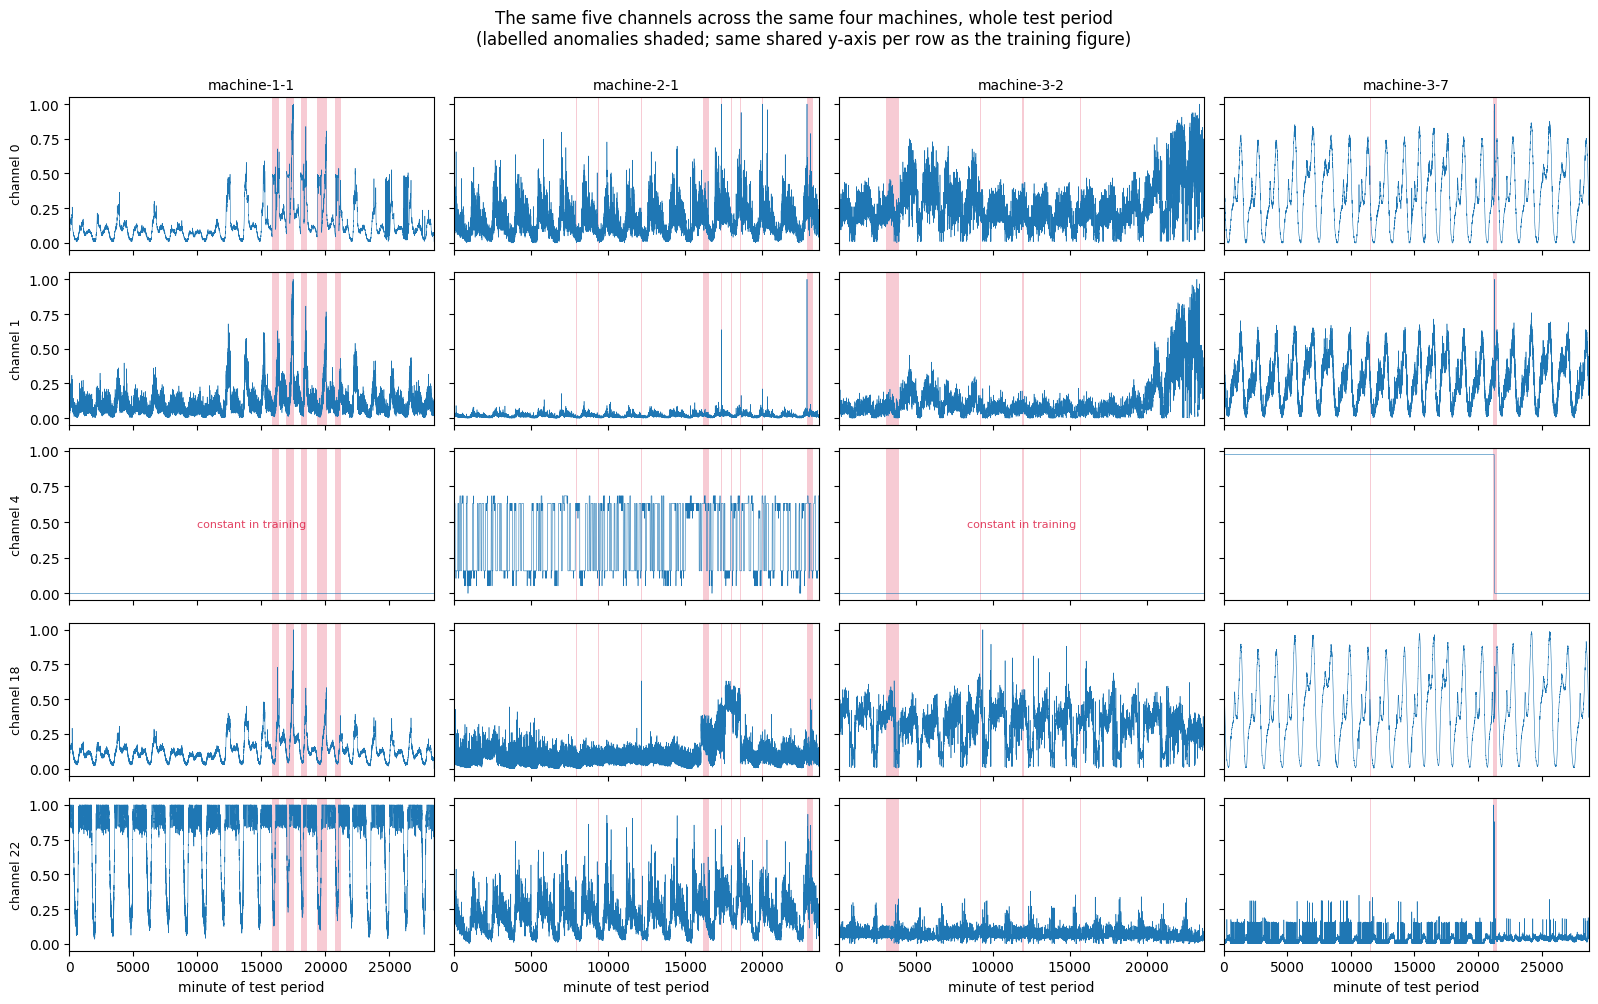

    machine  n_test  anomaly_rate  n_segments  longest_segment
machine-1-1   28479      0.094596           8              721
machine-2-1   23694      0.049380          13              452
machine-3-2   23703      0.046787          10              837
machine-3-7   28705      0.015119           5              311

test-period std as a multiple of training std (NaN = constant in training):
    machine-1-1  machine-2-1  machine-3-2  machine-3-7
0          2.40         1.12         1.26         0.95
1          2.40         1.46         1.55         0.97
4           NaN         0.95          NaN        37.07
18         2.06         0.51         0.86         1.02
22         1.00         1.02         0.98         0.96


In [4]:
# The same channels and machines again, now over the whole test period, with the labelled
# anomalies shaded. (The `segments` helper defined in the next cell formalises this edge
# detection; it is inlined here so this figure does not depend on a later cell.)
fig, axes = plt.subplots(len(COMPARE_CHANNELS), len(COMPARE_MACHINES),
                         figsize=(16, 10), sharex='col', sharey='row')

test_summary, drift = [], {}
for column, name in enumerate(COMPARE_MACHINES):
    machine_train, machine_test, machine_labels = load_machine(name)

    edges = np.diff(np.concatenate([[0], machine_labels.astype(int), [0]]))
    spans = list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)))

    test_summary.append({
        'machine': name, 'n_test': len(machine_test),
        'anomaly_rate': float(machine_labels.mean()), 'n_segments': len(spans),
        'longest_segment': max((hi - lo for lo, hi in spans), default=0),
    })
    # How much louder each channel gets in the test period - a channel that barely moves
    # here is one the labelled anomalies do not express themselves through.
    drift[name] = (machine_test[COMPARE_CHANNELS].std()
                   / machine_train[COMPARE_CHANNELS].std().replace(0, np.nan))

    for row, channel in enumerate(COMPARE_CHANNELS):
        ax = axes[row, column]
        ax.plot(machine_test[channel].to_numpy(), lw=0.4, color='#1f77b4')
        for lo, hi in spans:
            ax.axvspan(lo, hi, color='crimson', alpha=0.22, lw=0)
        ax.margins(x=0)

        if machine_train[channel].std() == 0:
            ax.text(0.5, 0.5, 'constant in training', transform=ax.transAxes, ha='center',
                    va='center', fontsize=8, color='crimson', alpha=0.8)
        if row == 0:
            ax.set_title(name, fontsize=10)
        if column == 0:
            ax.set_ylabel('channel {0}'.format(channel), fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel('minute of test period')

fig.suptitle('The same five channels across the same four machines, whole test period\n'
             '(labelled anomalies shaded; same shared y-axis per row as the training figure)',
             y=1.0)
plt.tight_layout()
plt.show()

print(pd.DataFrame(test_summary).to_string(index=False))
print('\ntest-period std as a multiple of training std (NaN = constant in training):')
print(pd.DataFrame(drift).to_string(float_format=lambda v: '{0:.2f}'.format(v)))

**Where an anomaly shows up is as machine-specific as the normal behaviour is.**

- machine-1-1's eight labelled segments coincide with a clear amplitude increase on channels
  0, 1 and 18 - the test-period standard deviation is 2.0x to 2.4x its training value on
  exactly those channels, and 1.00x on channel 22. Even within a single machine the labelled
  anomalies express themselves through some channels and not others, which is what the
  interpretation labels record, and why the channels are kept together in one path rather
  than scored independently.

- **machine-3-7's channel 4 is the sharpest single example in the figure.** It sits pinned
  near 1.0 through the entire training period and most of the test period, then steps to 0
  exactly at the labelled anomaly around minute 21,000 - a test-to-training standard
  deviation ratio of 37x, far the largest in the table. A channel that barely moves during
  training is not necessarily uninformative; it can be the one that moves when something
  breaks. It is the standing argument against dropping channels that look dead in
  training - a filter on training variance would have discarded the single clearest
  anomaly signal in this figure had its training deviation been a shade smaller.

- **machine-3-2's most dramatic behaviour is not labelled at all.** Channels 0 and 1 undergo
  a large, sustained amplitude increase from roughly minute 20,000 to the end of the test
  period, and none of it is shaded; its labelled anomalies are a block near minute 3,500 and
  a few thin segments through the middle. Any detector keying on "this no longer looks like
  the training period" will flag that late regime change and be scored wrong for doing so.

That last point is worth carrying forward. Section 9 reports machine-3-2 with the lowest AUC
of all 28 machines - 0.582, barely above chance - and treats it as the one machine where the
representation itself failed. This figure suggests a less flattering reading of the metric is
also available: the scores may be picking out real structure that the labels do not mark. AUC
measures agreement with the labels, and on this machine the labels and the visible structure
disagree.

In [5]:
MACHINE = 'machine-1-1'
train, test, labels = load_machine(MACHINE)
print('{0}: train {1}, test {2}, {3:.2%} of test points anomalous'.format(
    MACHINE, train.shape, test.shape, labels.mean()))


def segments(mask):
    """Contiguous True runs of a boolean mask, as (start, end_exclusive) pairs."""
    edges = np.diff(np.concatenate([[0], mask.astype(int), [0]]))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)))


true_segments = segments(labels)
lengths = [hi - lo for lo, hi in true_segments]
print('{0} anomalous segments, lengths {1} to {2} (median {3})'.format(
    len(true_segments), min(lengths), max(lengths), int(np.median(lengths))))

machine-1-1: train (28479, 38), test (28479, 38), 9.46% of test points anomalous
8 anomalous segments, lengths 2 to 721 (median 433)


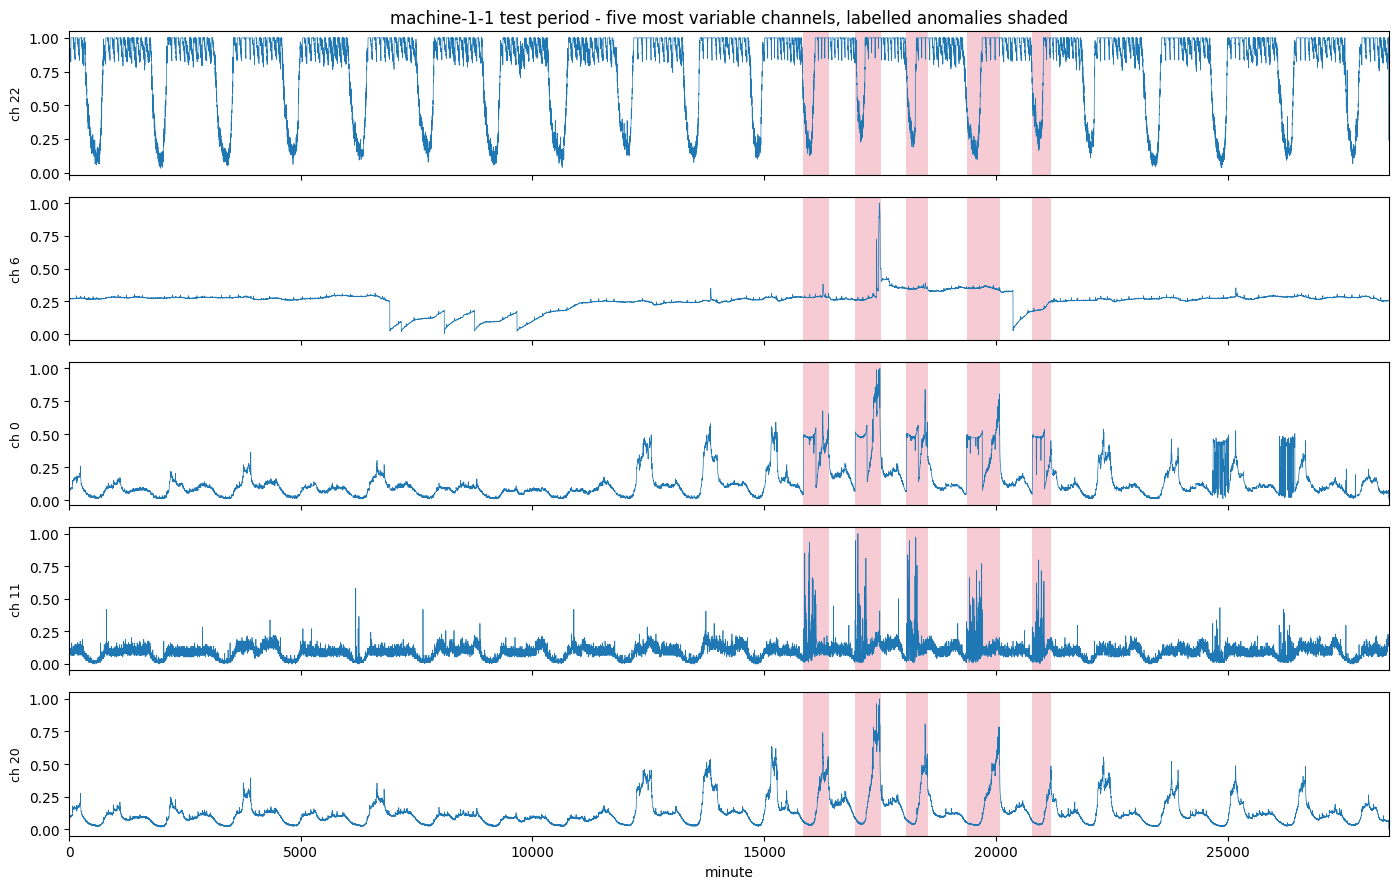

In [6]:
# The five most variable channels, with the labelled anomalies shaded.
busiest = train.std().sort_values(ascending=False).index[:5]

fig, axes = plt.subplots(len(busiest), 1, figsize=(14, 9), sharex=True)
for ax, channel in zip(axes, busiest):
    ax.plot(test[channel].to_numpy(), lw=0.5, color='#1f77b4')
    for lo, hi in true_segments:
        ax.axvspan(lo, hi, color='crimson', alpha=0.22, lw=0)
    ax.set_ylabel('ch {0}'.format(channel), fontsize=9)
    ax.margins(x=0)
axes[0].set_title('{0} test period - five most variable channels, labelled anomalies shaded'
                  .format(MACHINE))
axes[-1].set_xlabel('minute')
plt.tight_layout()
plt.show()

The anomalies are visibly *structural* rather than simple spikes: sustained regime changes
lasting hundreds of minutes, often visible in some channels and entirely absent from others.
That is encouraging for a signature method, which describes the shape of a path over an
interval rather than the magnitude at a point - and it is the case the widest-first search is
built for, since a regime change occupies a contiguous stretch that bisection can bracket.

In [7]:
# The interpretation labels say which channels explain each anomaly.
interpretation = []
with open(SMD / 'interpretation_label' / (MACHINE + '.txt'), encoding='utf-8') as handle:
    for line in handle:
        span, dims = line.strip().split(':')
        lo, hi = span.split('-')
        interpretation.append((int(lo), int(hi), [int(d) for d in dims.split(',')]))

print('{0} interpreted segments; channels implicated per segment:'.format(len(interpretation)))
for lo, hi, dims in interpretation[:6]:
    print('  {0:6d}-{1:<6d} ({2:4d} min)  {3:2d} channels: {4}'.format(
        lo, hi, hi - lo, len(dims), dims[:12]))

counts = pd.Series([d for _, _, dims in interpretation for d in dims]).value_counts()
print('\nmost frequently implicated channels (1-indexed):')
print(counts.head(10).to_string())

8 interpreted segments; channels implicated per segment:
   15849-16368  ( 519 min)   7 channels: [1, 9, 10, 12, 13, 14, 15]
   16963-17517  ( 554 min)  31 channels: [1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14]
   18071-18528  ( 457 min)   8 channels: [1, 2, 9, 10, 12, 13, 14, 15]
   19367-20088  ( 721 min)  14 channels: [1, 2, 3, 4, 9, 10, 11, 12, 13, 14, 15, 16]
   20786-21195  ( 409 min)   7 channels: [1, 9, 10, 12, 13, 14, 15]
   24679-24682  (   3 min)   4 channels: [9, 13, 14, 15]

most frequently implicated channels (1-indexed):
9     8
14    8
13    8
15    8
1     5
10    5
12    5
2     3
3     2
4     2


Anomalies implicate anywhere from 7 to 31 of the 38 channels at once. A per-channel detector
run independently on each dimension would therefore have plenty of chances to notice
something - but would also throw away exactly the cross-channel structure that distinguishes
"several channels moved together, as they always do" from "several channels moved together in
a combination never seen before". Keeping the channels in one path is the more interesting
test of the method, so that is what follows.

## 2. The dimensionality wall

This is the first genuinely new obstacle, and it constrains both detectors equally. A
truncated signature of a `width`-dimensional path at level `trunc` has
`sum(width**k for k in 1..trunc)` terms. On the toy data `width` was 2 - time plus one
value - and level 5 cost 62 terms. With 38 channels plus time, `width` is 39:

In [8]:
table = pd.DataFrame(
    {'trunc {0}'.format(m): [iisignature.siglength(w, m) for w in (2, 5, 9, 31, 39)]
     for m in (1, 2, 3, 4)},
    index=['width 2 (toy)', 'width 5', 'width 9', 'width 31 (SMD, were constants dropped)',
           'width 39 (SMD, all channels)'])
print(table.to_string())

                                        trunc 1  trunc 2  trunc 3  trunc 4
width 2 (toy)                                 2        6       14       30
width 5                                       5       30      155      780
width 9                                       9       90      819     7380
width 31 (SMD, were constants dropped)       31      992    30783   954304
width 39 (SMD, all channels)                 39     1560    60879  2374320


Level 3 on the full channel set is 60,879 terms per interval, and a dense whitening is a
`D x D` matrix - 3.7 billion entries, roughly 30 GB in float64. Level 4 is off the scale
entirely. **Level 2 is the ceiling**, and dropping the constant channels brings it from
1,560 to 992 terms.

That is not merely a memory constraint, it is a statistical one, and it is the reason the
rank rule in section 5 matters. Signature level *k* captures how the path's channels co-vary
across *k* successive sub-intervals, so truncating at 2 keeps increments and pairwise areas
(the Levy area between each pair of channels) but discards every third-order interaction. On
the toy data, levels 3-5 were what separated `doubled_frequency` from normal. Here we are
betting that 38 channels' worth of pairwise structure compensates for the lost depth.

Note the two detectors sit at opposite ends of one trade-off this creates. Detector A
estimates a single covariance from every interval in the corpus pooled together - many
samples, but drawn from intervals of wildly different widths. Detector B estimates a
covariance per interval from only as many samples as there are training windows - far fewer
samples, but all of them at exactly the right scale.

## 3. Preparing SMD, and the three-way split

The pipeline consumes *windows* - one file per stream, each a `(length, 1 + channels)` table
with a time column. Three preparation decisions:

**Keep every channel, including the ones that never move in training.** This follows the
pipeline, which keeps them deliberately, and there are two reasons. A channel that is
constant during training can be exactly the one that moves when something breaks -
machine-3-7's channel 4 above steps from 1 to 0 precisely at its labelled anomaly. And
dropping them is not needed for the metric's sake: a zero-variance direction is annihilated
by the pseudo-inverse rather than amplified by it, so a constant channel contributes
nothing to the Mahalanobis distance instead of dividing by zero in it. The cost of keeping
them is dimensional - SMD's width goes from 32 to 39, and `siglength` grows with it.

**Normalise the time channel to `[0, 1]` per window.** If time is left as a row index it
spans 0-99 while every value channel lies in [0, 1], so the time channel would dominate every
signature term it appears in and the level-2 areas would be swamped. This is the SMD-specific
instance of the normalisation the workflow's `cleaning.py` stage is meant to handle generally.

**Window at 100 points, stride 50.** A 100-minute window with granularity 3 bisects down to
intervals of ~12 minutes, well below the median anomaly length of 433 minutes.

The training half is then split by window into **fit** (80%) and **withheld** (20%). Both are
normal; the difference is that the metric is fitted on the fit set only, so the withheld
windows are genuinely unseen normal data. The workflow's `split` rule produces two ways
(base/test) and needs a third for exactly this.

In [9]:
WINDOW, STRIDE = 100, 50
TRUNC, GRANULARITY = 2, 3
BAND = 1
SIG_TOL, TOL = 2, 2            # resolution floor 4 points, boundary step 4 points
FIT_FRACTION = 0.8

# Section 9 scores all 28 machines and is about 80% of this notebook's runtime - 1h 33m of
# the 117 minutes spent in timed cells. Set this False for a development run, which scores a
# spread of SAMPLE_MACHINES instead and takes the whole notebook from roughly two and a half
# hours to about thirty-five minutes.
#
# Any figure quoted anywhere should come from the full sweep. Section 9's own finding is the
# reason: an earlier draft scored four machines chosen to span the anomaly-rate range and got
# the ordering of the two detectors backwards. A subsample is for iterating, not for
# concluding.
RUN_ALL_MACHINES = True
SAMPLE_MACHINES = 6


def prepare_windows(frame, stem, directory):
    """Write one parquet per window and return {file stem: global start row}.

    The offset map is what lets flagged intervals - which the search reports in window-local
    point indices - be mapped back onto the labelled test series.
    """
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    for stale in directory.glob('*.parquet'):
        stale.unlink()

    offsets = {}
    for i in range((len(frame) - WINDOW) // STRIDE + 1):
        lo = i * STRIDE
        window = frame.iloc[lo:lo + WINDOW].reset_index(drop=True)
        window.columns = ['ch{0}'.format(c) for c in window.columns]
        window.insert(0, 'time', np.linspace(0.0, 1.0, WINDOW))
        name = '{0}_{1:05d}'.format(stem, i)
        window.to_parquet(directory / (name + '.parquet'))
        offsets[name] = lo
    return offsets


def prepare_machine(name):
    """Window one machine into fit / withheld / test, keeping every channel.

    Returns the window files for each split, the stacked path arrays the per-interval
    detector needs, and the offset maps for scoring.
    """
    train, test, labels = load_machine(name)
    keep = train.columns

    base_offsets = prepare_windows(train[keep], name + '_base', WORK / (name + '_base'))
    test_offsets = prepare_windows(test[keep], name + '_test', WORK / (name + '_test'))

    base_files = sorted((WORK / (name + '_base')).glob('*.parquet'))
    test_files = sorted((WORK / (name + '_test')).glob('*.parquet'))
    cut = int(round(FIT_FRACTION * len(base_files)))

    # The same files, stacked into one array, so detector B can slice every window to the
    # same interval at once. Loaded through load_stream so both detectors see byte-identical
    # data rather than two independent constructions of it.
    stack = lambda files: np.stack([load_stream(f, time_col='time') for f in files])

    return {
        'name': name, 'keep': list(keep), 'labels': labels,
        'fit_files': base_files[:cut], 'held_files': base_files[cut:], 'test_files': test_files,
        'fit_paths': stack(base_files[:cut]), 'held_paths': stack(base_files[cut:]),
        'test_paths': stack(test_files),
        'base_offsets': base_offsets, 'test_offsets': test_offsets,
    }


spec = prepare_machine(MACHINE)
fit_files, held_files, test_files = spec['fit_files'], spec['held_files'], spec['test_files']
fit_paths, held_paths, test_paths = spec['fit_paths'], spec['held_paths'], spec['test_paths']
width = fit_paths.shape[2]

print('all {0} channels kept -> path width {1}, signature dimension {2}'.format(
    len(spec['keep']), width, iisignature.siglength(width, TRUNC)))
print('{0} fit / {1} withheld / {2} test windows'.format(
    len(fit_files), len(held_files), len(test_files)))

all 38 channels kept -> path width 39, signature dimension 1560
454 fit / 114 withheld / 568 test windows


## 4. An evaluation protocol

`scoring.py` in the package is still empty, and the workflow's `evaluate` rule is a
placeholder for exactly this reason: until now there were no labels to score against. The
functions below are what that module should become.

Both detectors report **intervals**; the labels are **per point**. Flagged intervals are
therefore rasterised onto a boolean mask over the test series, using the window offsets
recorded during preparation, and scored point-wise.

Two metrics are reported throughout:

- **Point-wise F1** - the strict reading. Every flagged minute must be a genuinely anomalous
  minute.
- **Point-adjusted F1** - the convention used by OmniAnomaly and most SMD papers: if *any*
  point inside a true anomalous segment is flagged, the whole segment counts as detected.

Point-adjust is reported because it is what published SMD numbers use and comparisons are
otherwise meaningless, but it is badly inflated - a single lucky point inside a 700-minute
segment scores the entire segment as a hit, so it rewards a detector that fires roughly
everywhere. Both are shown side by side, always with the flagged fraction, so that inflation
stays visible rather than being quietly banked.

In [10]:
def flagged_to_mask(flagged, offsets, n_points):
    """Rasterise flagged intervals onto a boolean mask over the whole test series.

    Overlapping windows mean a point can be flagged by more than one window; the union is
    taken, so one window's detection is enough.
    """
    mask = np.zeros(n_points, dtype=bool)
    for row in flagged.itertuples():
        start = offsets[row.stream]
        mask[start + row.start_index: start + row.end_index + 1] = True
    return mask


def point_adjust(predicted, truth):
    """Expand each true segment to fully flagged if any point within it was flagged."""
    adjusted = predicted.copy()
    for lo, hi in segments(truth):
        if adjusted[lo:hi].any():
            adjusted[lo:hi] = True
    return adjusted


def metrics(predicted, truth):
    """Point-wise and point-adjusted precision / recall / F1, plus the flagged fraction."""
    def prf(pred):
        tp = int((pred & truth).sum())
        fp = int((pred & ~truth).sum())
        fn = int((~pred & truth).sum())
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        return precision, recall, f1

    precision, recall, f1 = prf(predicted)
    _, adj_recall, adj_f1 = prf(point_adjust(predicted, truth))
    return {'precision': precision, 'recall': recall, 'f1': f1,
            'adj_recall': adj_recall, 'adj_f1': adj_f1,
            'flagged_frac': float(predicted.mean())}


def show(label, result):
    print('{0:<30} P {precision:.3f}  R {recall:.3f}  F1 {f1:.3f}   |   '
          'adjF1 {adj_f1:.3f}   flagged {flagged_frac:.1%}'.format(label, **result))


# The floor any detector must beat: flag every single point.
everything = np.ones(len(labels), dtype=bool)
result_all = metrics(everything, labels)
show('flag everything', result_all)
show('flag nothing', metrics(np.zeros(len(labels), dtype=bool), labels))

flag everything                P 0.095  R 1.000  F1 0.173   |   adjF1 0.173   flagged 100.0%
flag nothing                   P 0.000  R 0.000  F1 0.000   |   adjF1 0.000   flagged 0.0%


Note how flattering point-adjusted F1 is to the degenerate detector: flagging everything
scores a *perfect* adjusted recall by construction. Any adjusted number must be read against
the flagged fraction beside it.

## 5. The calibration protocol

Both detectors need a threshold, and the threshold is where this method lives or dies. The
protocol used for both is three steps:

1. **Train.** Fit the Mahalanobis metric on the fit windows only. Nothing else ever
   influences the metric.
2. **Calibrate.** Score the withheld windows - normal, but never seen by the metric - and put
   the threshold at a high percentile of *those* scores.
3. **Fold in.** Add the withheld windows to the reference set the detector actually searches,
   so detection runs against every normal window available rather than only 80% of them.

Step 2 is the fix for a specific failure. Step 3 is what stops the calibration data from
being thrown away afterwards, and it has a consequence that has to be handled. This section
establishes both, using detector A's pooled corpus as the vehicle; detector B applies exactly
the same three steps interval by interval.

### 5.1 The corpus cannot calibrate itself

`calibrate_threshold` - the function the Snakefile's `calibrate` rule calls - derives the
threshold from the corpus's own nearest-neighbour distances. Build the corpus and see what
that gives.

In [11]:
%%time
# Step 1: the corpus of normality, from the fit windows only.
corpus_fit = create_corpus_merged(fit_files, trunc=TRUNC, granularity=GRANULARITY,
                                  time_col='time')
corpus_held = create_corpus_merged(held_files, trunc=TRUNC, granularity=GRANULARITY,
                                   time_col='time')
corpus_final = pd.concat([corpus_fit, corpus_held], ignore_index=True)

signatures_fit, depths_fit = split_corpus(corpus_fit)
print('fit corpus       {0} intervals x {1} signature terms'.format(*signatures_fit.shape))
print('withheld corpus  {0} intervals'.format(len(corpus_held)))
print('final corpus     {0} intervals (fit + withheld)'.format(len(corpus_final)))
print('\nintervals per depth (fit corpus):')
print(corpus_fit['depth'].value_counts().sort_index().to_string())

fit corpus       6810 intervals x 1560 signature terms
withheld corpus  1710 intervals
final corpus     8520 intervals (fit + withheld)

intervals per depth (fit corpus):
depth
0     454
1     908
2    1816
3    3632
CPU times: total: 4 s
Wall time: 3.26 s


In [12]:
import warnings
from anomalies_scale.anomaly_detection_pooled import calibrate_threshold

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    in_sample = calibrate_threshold(corpus_fit, statistic='p99', band=BAND)

print('calibrate_threshold (p99, in-sample) = {0:.1f}'.format(in_sample['threshold']))
print('per-depth median spread: {0:.1f}x   (module warns above 10x)'.format(in_sample['spread']))
for w in caught:
    print('WARNING:', w.message)
print()
print(pd.DataFrame(in_sample['per_depth']).to_string(index=False))

calibrate_threshold (p99, in-sample) = 5487.9
per-depth median spread: 4.0x   (module warns above 10x)

 depth  n_intervals  median         p90         p99    max
     0          454   855.5 1551.799927 5487.850098 6594.0
     1          908   329.5  738.599976 3126.029541 4397.0
     2         1816   214.0  534.000000 2086.000000 4493.0
     3         3632   251.0 1233.000000 4952.080078 6983.0


The spread is around 4x - comfortably under the module's 10x warning level. On that evidence
a single scalar threshold looks defensible, and nothing here suggests a problem. The problem
only appears when the same corpus is asked about data it has not seen.

In [13]:
def interval_scores(pooled, frame, exclude_self=False):
    """Batched equivalent of PooledCorpus.score over an entire corpus frame.

    Queries each depth's FAISS index once rather than once per interval. Reaches into
    `pooled._index` to do so; promoting a `score_many` to the module would remove the need.

    `exclude_self` is essential when `frame`'s rows are themselves in the index: every point
    is then its own nearest neighbour at distance zero, so the second neighbour is the one
    that means anything. This is the same k=2 trick `score_distribution` uses.
    """
    signatures, depths = split_corpus(frame)
    out = np.empty(len(signatures))
    k = 2 if exclude_self else 1
    for depth in np.unique(depths):
        rows = np.flatnonzero(depths == depth)
        queries = np.ascontiguousarray(
            (signatures[rows] @ pooled.covariance.T).astype('float32'))
        distances, _ = pooled._index(int(depth)).search(queries, k)
        out[rows] = distances[:, k - 1]
    return out


# The module's default whitening, so this compares like with like against calibrate_threshold.
default_pooled = PooledCorpus(corpus_fit, band=BAND, check_scale=False)
scores_in = interval_scores(default_pooled, corpus_fit, exclude_self=True)
scores_held = interval_scores(default_pooled, corpus_held)

print(pd.DataFrame([
    {'set': 'fit corpus (in-sample, k=2)', 'n': len(scores_in),
     'median': float(np.median(scores_in)), 'p99': float(np.percentile(scores_in, 99))},
    {'set': 'withheld NORMAL (unseen)', 'n': len(scores_held),
     'median': float(np.median(scores_held)), 'p99': float(np.percentile(scores_held, 99))},
]).to_string(index=False))

print('\nthreshold calibrate_threshold chose: {0:.1f}'.format(in_sample['threshold']))
print('fraction of withheld NORMAL intervals already above it: {0:.1%}'.format(
    float((scores_held > in_sample['threshold']).mean())))
print('in-sample median understates unseen-normal median by {0:.1f}x'.format(
    float(np.median(scores_held) / np.median(scores_in))))

                        set    n  median       p99
fit corpus (in-sample, k=2) 6810   269.0   4329.73
   withheld NORMAL (unseen) 1710  3576.5 166504.35

threshold calibrate_threshold chose: 5487.9
fraction of withheld NORMAL intervals already above it: 35.6%
in-sample median understates unseen-normal median by 13.3x


**This is the failure the protocol exists to fix.** The corpus's own internal distances
understate what genuinely normal but unseen data scores by more than an order of magnitude,
so a threshold derived from them sits *below* the median of normal-but-unseen intervals. A
detector using it flags normal data as a matter of course - not because the representation
cannot tell anomalies from normality, but because it is measuring "was this in the training
set" rather than "is this unusual".

Note also the `exclude_self=True` above. Scoring a corpus against an index that contains it
finds every point matching itself at distance zero; `score_distribution` already handles this
by taking the second neighbour, and any diagnostic comparing in-sample to out-of-sample
scores has to do the same or the comparison is meaningless.

### 5.2 Why in-sample distances understate: the rank rule

The mechanism is over-fitted whitening. The covariance is `992 x 992`, estimated from 6,810
intervals, and the signature corpus is nothing like full rank in any practical sense:

signature dimension D = 1560, fit intervals N = 6810  (N/D = 4.4)
numerical rank at rcond=1e-12 (the module default): 992
  components carrying 90.0% of variance: 5
  components carrying 99.0% of variance: 21
  components carrying 99.9% of variance: 56


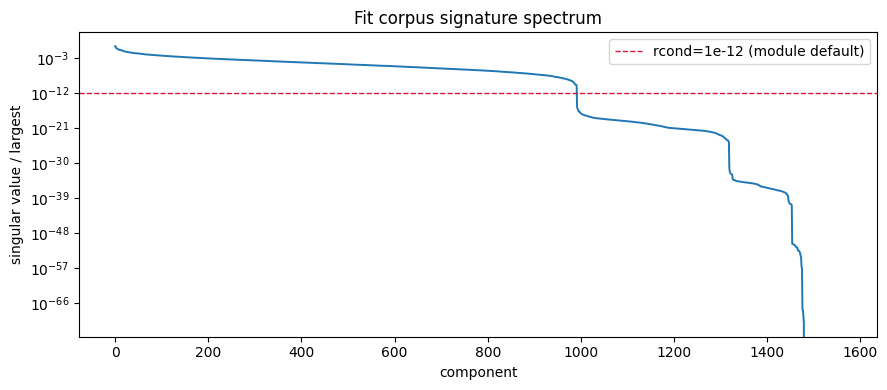

In [14]:
centred = signatures_fit - signatures_fit.mean(axis=0)
spectrum = np.linalg.svd(np.linalg.qr(centred, mode='r'), compute_uv=False)
variance = np.cumsum(spectrum ** 2) / np.sum(spectrum ** 2)

print('signature dimension D = {0}, fit intervals N = {1}  (N/D = {2:.1f})'.format(
    signatures_fit.shape[1], signatures_fit.shape[0],
    signatures_fit.shape[0] / signatures_fit.shape[1]))
print('numerical rank at rcond=1e-12 (the module default): {0}'.format(
    int((spectrum > 1e-12 * spectrum.max()).sum())))
for target in (0.90, 0.99, 0.999):
    print('  components carrying {0:.1%} of variance: {1}'.format(
        target, int(np.searchsorted(variance, target) + 1)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(spectrum / spectrum.max(), lw=1.4)
ax.axhline(1e-12, color='crimson', ls='--', lw=1, label='rcond=1e-12 (module default)')
ax.set_xlabel('component'); ax.set_ylabel('singular value / largest')
ax.set_title('Fit corpus signature spectrum')
ax.legend(); plt.tight_layout(); plt.show()

`rcond=1e-12` declares all 992 directions usable and the whitening divides by every one of
them. In the directions where the corpus has essentially no spread, `Sigma^-1/2` applies an
enormous multiplier - and those directions are fitted to this particular sample, so they
describe sampling noise rather than structure. Corpus points sit inside that noise by
construction; anything else, anomalous or not, is thrown far away along axes that mean
nothing.

Rather than pick an `rcond` by hand, both detectors here use a **retained-variance rule**:
keep the leading components carrying `VARIANCE_KEEP` of the corpus's signature variance and
discard the rest. This is what section 9 of the previous version of this notebook recommended
- a rank rule that adapts to the corpus rather than a constant - and it matters more for
detector B, whose per-interval corpora have only as many rows as there are fit windows.

The rule is fixed a priori at 99.9% and used unchanged for both detectors and every machine.
It is deliberately *not* tuned against the test labels: doing so would be leakage, and the
whole point of section 8 is to see what transfers.

In [15]:
VARIANCE_KEEP = 0.999
PERCENTILE = 99.9


def variance_rank(signatures, keep=VARIANCE_KEEP):
    """Rank retaining `keep` of the signature variance, and the rcond that selects it.

    Returned as an rcond so it can be handed straight to `build_whitening`, which expresses
    its cutoff as a fraction of the largest singular value.
    """
    X = np.asarray(signatures, dtype=float)
    centred = X - X.mean(axis=0)
    R = np.linalg.qr(centred, mode='r') if centred.shape[0] > centred.shape[1] else centred
    s = np.linalg.svd(R, compute_uv=False)
    energy = np.cumsum(s ** 2) / np.sum(s ** 2)
    rank = min(int(np.searchsorted(energy, keep) + 1), int((s > 1e-12 * s.max()).sum()))
    return rank, float(s[rank - 1] / s[0]) * (1 - 1e-9)


rank_fit, rcond_fit = variance_rank(signatures_fit)
whitening = build_whitening(signatures_fit, rcond=rcond_fit)
print('metric trained on {0} fit intervals: rank {1} of {2} (rcond {3:.2e})'.format(
    len(signatures_fit), rank_fit, signatures_fit.shape[1], rcond_fit))

metric trained on 6810 fit intervals: rank 56 of 1560 (rcond 1.09e-02)


### 5.3 Folding the withheld data back in moves every score

Step 3 says the withheld windows join the reference set once they have done their
calibration job. That is worth doing - they are 20% more normal data, and coverage of
normality is exactly what a nearest-neighbour detector is short of. But it is not free:
adding points to a reference set can only ever *reduce* nearest-neighbour distances, because
the new points are extra candidates for "nearest". Every score shifts down, and a threshold
calibrated against the smaller reference set is then too high.

So there are two ways to run step 2, and the difference is measurable:

- **naive** - score the withheld intervals against the *fit-only* index, take the percentile,
  then enlarge the index. The threshold is on the wrong scale by the time it is used.
- **self-excluded** - build the final index first, score each withheld interval against it
  while skipping its own zero-distance self-match, and take the percentile of that. The
  threshold is measured on exactly the reference set the detector will search.

withheld scores against the fit-only index : median      30.8   p99.9     406.8
withheld scores against the final index    : median      21.0   p99.9     204.0

the naive threshold is 1.99x too high for the index it will be used against


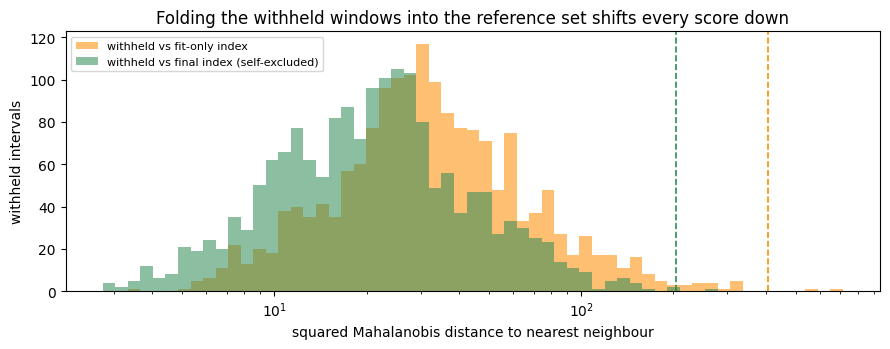

In [16]:
pooled_fit_only = PooledCorpus(corpus_fit, covariance=whitening, band=BAND, check_scale=False)
pooled_final = PooledCorpus(corpus_final, covariance=whitening, band=BAND, check_scale=False)

held_vs_fit_only = interval_scores(pooled_fit_only, corpus_held)
held_vs_final = interval_scores(pooled_final, corpus_held, exclude_self=True)

threshold_naive = float(np.percentile(held_vs_fit_only, PERCENTILE))
threshold_pooled = float(np.percentile(held_vs_final, PERCENTILE))

print('withheld scores against the fit-only index : median {0:9.1f}   p{1} {2:9.1f}'.format(
    float(np.median(held_vs_fit_only)), PERCENTILE, threshold_naive))
print('withheld scores against the final index    : median {0:9.1f}   p{1} {2:9.1f}'.format(
    float(np.median(held_vs_final)), PERCENTILE, threshold_pooled))
print('\nthe naive threshold is {0:.2f}x too high for the index it will be used against'
      .format(threshold_naive / threshold_pooled))

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.logspace(np.log10(max(held_vs_final.min(), 1e-6)),
                   np.log10(held_vs_fit_only.max()), 60)
ax.hist(held_vs_fit_only, bins=bins, alpha=0.55, label='withheld vs fit-only index',
        color='darkorange')
ax.hist(held_vs_final, bins=bins, alpha=0.55, label='withheld vs final index (self-excluded)',
        color='seagreen')
ax.axvline(threshold_naive, color='darkorange', ls='--', lw=1.2)
ax.axvline(threshold_pooled, color='seagreen', ls='--', lw=1.2)
ax.set_xscale('log'); ax.set_xlabel('squared Mahalanobis distance to nearest neighbour')
ax.set_ylabel('withheld intervals')
ax.set_title('Folding the withheld windows into the reference set shifts every score down')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The shift is real and it is not small. Both thresholds are defensible percentiles of
genuinely-normal unseen data; they differ only in which reference set the distances were
measured against, and that alone moves the number by a factor of two. Section 6 runs the
detector at both to show what that costs.

The self-excluded threshold is the right one, and the reason is worth stating precisely: it
is measured under the same conditions the detector will operate under - same metric, same
reference set, and the query not present in its own neighbour set. The naive one answers a
question nobody asked, namely how far unseen normal data sits from 80% of the corpus, when
the detector will be searching 100% of it.

## 6. Detector A: widest-first search over a pooled corpus

Everything is now in place to run the packaged detector unmodified. `detect_anomalies` is the
pysegments-style search - `widest_first_segment` with a characteristic function that scores
each candidate interval against the pooled corpus - and it takes the corpus, the metric and
the threshold as arguments, so the protocol above slots straight in:

- corpus: `corpus_final`, the fit **and** withheld windows (step 3)
- metric: `whitening`, trained on the fit windows only (step 1)
- threshold: `threshold_pooled`, calibrated on the withheld windows against that same final
  index (step 2)

In [17]:
%%time
from anomalies_scale.anomaly_detection_pooled import detect_anomalies

flagged_pooled = detect_anomalies(test_files, corpus_final, threshold=threshold_pooled,
                                  covariance=whitening, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                                  time_col='time')
mask_pooled = flagged_to_mask(flagged_pooled, spec['test_offsets'], len(labels))
result_pooled = metrics(mask_pooled, labels)

flagged_naive = detect_anomalies(test_files, corpus_final, threshold=threshold_naive,
                                 covariance=whitening, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                                 time_col='time')
result_naive = metrics(flagged_to_mask(flagged_naive, spec['test_offsets'], len(labels)), labels)

print('{0} intervals flagged at the self-excluded threshold'.format(len(flagged_pooled)))
print()
show('A: pooled, self-excluded thr', result_pooled)
show('A: pooled, naive threshold', result_naive)
show('flag everything', result_all)

136 intervals flagged at the self-excluded threshold

A: pooled, self-excluded thr   P 0.413  R 0.383  F1 0.398   |   adjF1 0.785   flagged 8.8%
A: pooled, naive threshold     P 0.480  R 0.291  F1 0.362   |   adjF1 0.863   flagged 5.7%
flag everything                P 0.095  R 1.000  F1 0.173   |   adjF1 0.173   flagged 100.0%
CPU times: total: 1min 37s
Wall time: 48.8 s


The naive threshold under-flags exactly as predicted - it was calibrated against a sparser
reference set, so it demands more unusualness than the enlarged corpus warrants. Same corpus,
same metric, same search; only the scale the threshold was measured on differs.

## 7. Detector B: corpus and metric recomputed per interval

Detector A pools every interval, of every width, into one corpus and fits one metric to all
of it. Depth banding limits which of those intervals a query is compared against, but the
whitening is still global - one `Sigma^-1/2` estimated across intervals spanning relative
widths from 1 down to 1/8.

Detector B removes that compromise. When the search asks about interval `[lo, hi]` of a test
window, the reference set is built by slicing **every training window to that same
`[lo, hi]`** and signing it, and the metric is fitted to those signatures alone. The
comparison is then strictly like-for-like: a 25-point interval is judged against 25-point
intervals from the same position in normal windows, whitened by their own covariance.

This is the toy notebook's `pysegments_anomaly_detector` strategy. The three-step protocol
applies unchanged, just at interval granularity: the metric is fitted on the fit windows,
the threshold is the `PERCENTILE`-th percentile of the withheld windows' distances, and the
withheld windows then join the reference set the test interval is actually scored against.

**Two things make this affordable.** First, the reference set at `[lo, hi]` depends only on
`lo` and `hi`, not on which test window is being searched - every window shares one index
space - so each distinct interval is built once and memoised. The widest-first search visits
far fewer distinct intervals than one might expect (it only bisects where a test fails, and
boundary extension steps by `2 ** TOL`), and the count is reported below.

Second, the metric is stored as a projection rather than a `992 x 992` matrix. Whitening by
`Sigma^-1/2 = V diag(scale) V^T` and then taking a Euclidean norm is identical to projecting
onto `V diag(scale)` and taking the norm there, because `V` is orthonormal - so the reference
set lives in `rank` dimensions instead of 992, which is both faster to search and small
enough to cache. The equivalence is checked against `build_whitening` below rather than
assumed.

In [18]:
def sign_interval(paths, lo, hi, trunc=TRUNC):
    """Base-pointed signatures of every window in `paths`, restricted to points lo..hi."""
    raw = iisignature.sig(paths[:, lo:hi + 1, :], trunc)
    return add_base_point(raw, paths[:, lo, :], paths.shape[2], trunc)


def fit_projection(signatures, keep=VARIANCE_KEEP):
    """(D, rank) map P with ||(x - y) @ P||^2 equal to the Mahalanobis distance.

    Same construction as `build_whitening`, stopped one step earlier: that function forms
    the symmetric square root `V diag(scale) V^T`, and this returns `V diag(scale)`. Since
    V is orthonormal the two give identical distances, but this one lands in `rank`
    dimensions rather than D.
    """
    X = np.asarray(signatures, dtype=float)
    centred = X - X.mean(axis=0)
    R = np.linalg.qr(centred, mode='r') if centred.shape[0] > centred.shape[1] else centred
    _, s, Vt = np.linalg.svd(R, full_matrices=False)
    energy = np.cumsum(s ** 2) / np.sum(s ** 2)
    rank = min(int(np.searchsorted(energy, keep) + 1), int((s > 1e-12 * s.max()).sum()))
    return (Vt[:rank].T * (np.sqrt(len(X)) / s[:rank])).astype(np.float32), rank


# Check the projection against the module's own whitening at a matching rcond.
_probe = sign_interval(fit_paths, 0, WINDOW - 1)
_P, _rank = fit_projection(_probe)
_, _rcond = variance_rank(_probe)
_W = build_whitening(_probe, rcond=_rcond)
_a, _b = _probe[0], _probe[7]
_projected = float(np.sum(((_a - _b) @ _P) ** 2))
_full = float(np.sum(((_a - _b) @ _W.T) ** 2))
print('projection {0:.6g} vs build_whitening {1:.6g}   relative error {2:.1e}   (rank {3})'
      .format(_projected, _full, abs(_projected - _full) / _full, _rank))

projection 84.0922 vs build_whitening 84.0922   relative error 3.4e-09   (rank 54)


In [19]:
class PerIntervalReference:
    """Reference set and Mahalanobis metric rebuilt for each candidate interval.

    Calling `is_clean(signature, lo, hi)` builds - or reuses - the reference for exactly that
    interval and answers the search's characteristic function. Each build applies the three
    step protocol at interval granularity:

    1. sign the fit windows over [lo, hi] and fit the metric to them alone;
    2. sign the withheld windows over [lo, hi], score them against the *final* reference set
       with their own self-match excluded, and take the PERCENTILE-th percentile;
    3. leave the final reference set as fit + withheld, which is what queries search.

    Entries are memoised on (lo, hi), which is exact rather than approximate: the reference
    set depends only on the interval, since every window shares one index space.
    """

    def __init__(self, fit_paths, held_paths, trunc=TRUNC, keep=VARIANCE_KEEP,
                 percentile=PERCENTILE, cache_size=2048):
        self.fit_paths, self.held_paths = fit_paths, held_paths
        self.trunc, self.keep, self.percentile = trunc, keep, percentile
        self.cache_size = cache_size
        self._cache = OrderedDict()
        self.stats = {'builds': 0, 'cache_hits': 0, 'queries': 0, 'rank_total': 0}

    def _build(self, lo, hi):
        sig_fit = sign_interval(self.fit_paths, lo, hi, self.trunc)
        sig_held = sign_interval(self.held_paths, lo, hi, self.trunc)

        projection, rank = fit_projection(sig_fit, self.keep)          # step 1: fit only
        final = np.ascontiguousarray(
            np.vstack([sig_fit, sig_held]).astype(np.float32) @ projection)   # step 3
        index = faiss.IndexFlatL2(rank)
        index.add(final)

        # step 2: withheld against the final index, own self-match skipped
        distances, _ = index.search(np.ascontiguousarray(final[len(sig_fit):]), 2)
        threshold = float(np.percentile(distances[:, 1], self.percentile))

        self.stats['builds'] += 1
        self.stats['rank_total'] += rank
        return projection, index, threshold

    def reference(self, lo, hi):
        key = (lo, hi)
        if key in self._cache:
            self.stats['cache_hits'] += 1
            self._cache.move_to_end(key)
            return self._cache[key]
        entry = self._build(lo, hi)
        self._cache[key] = entry
        if len(self._cache) > self.cache_size:
            self._cache.popitem(last=False)
        return entry

    def score(self, signature, lo, hi):
        projection, index, threshold = self.reference(lo, hi)
        self.stats['queries'] += 1
        query = np.ascontiguousarray(np.asarray(signature, dtype=np.float32)[None, :] @ projection)
        distances, _ = index.search(query, 1)
        return float(distances[0, 0]), threshold

    @property
    def mean_rank(self):
        return self.stats['rank_total'] / max(self.stats['builds'], 1)

In [20]:
# `_invert` turns the clean intervals the search returns into the anomalous complement.
# It is private to the module only because `detect_anomalies` was until now its sole caller;
# driving the search directly, as detector B must, needs it too.
from anomalies_scale.anomaly_detection_pooled import _invert as invert_clean


def detect_per_interval(paths, names, reference, trunc=TRUNC, sig_tol=SIG_TOL, tol=TOL,
                        show_progress=False):
    """Widest-first search over each window, rebuilding the reference at every interval.

    Identical control flow to `detect_anomalies` - the same `widest_first_segment`,
    the same resolution floor and the same binary-search boundary extension -
    differing only in what the characteristic function compares against.
    """
    records = []
    for number, (name, path) in enumerate(zip(names, paths), start=1):
        signer = IntervalSigner(path, trunc)
        last = path.shape[0] - 1

        def is_clean(lo, hi):
            lo, hi = max(0, lo), min(last, hi)
            score, threshold = reference.score(signer.signature(lo, hi), lo, hi)
            return score <= threshold

        clean = widest_first_segment(0, last, is_clean, 2 ** sig_tol,
                                     floor=2 ** tol if tol else None)
        for lo, hi in invert_clean(clean, last):
            score, threshold = reference.score(signer.signature(lo, hi), lo, hi)
            records.append({'stream': name, 'start_index': int(lo), 'end_index': int(hi),
                            'score': score, 'threshold': threshold})
        if show_progress and number % 100 == 0:
            print('  {0}/{1} windows'.format(number, len(paths)))

    return pd.DataFrame(records,
                        columns=['stream', 'start_index', 'end_index', 'score', 'threshold'])

In [21]:
%%time
test_names = [f.stem for f in test_files]
reference = PerIntervalReference(fit_paths, held_paths)

flagged_per_interval = detect_per_interval(test_paths, test_names, reference,
                                           show_progress=True)
mask_per_interval = flagged_to_mask(flagged_per_interval, spec['test_offsets'], len(labels))
result_per_interval = metrics(mask_per_interval, labels)

print('\n{0} intervals flagged'.format(len(flagged_per_interval)))
print('{0} distinct intervals built, {1} cache hits over {2} queries ({3:.1%} hit rate)'.format(
    reference.stats['builds'], reference.stats['cache_hits'], reference.stats['queries'],
    reference.stats['cache_hits'] / max(reference.stats['queries'], 1)))
print('mean metric rank per interval: {0:.0f}'.format(reference.mean_rank))
print()
show('B: per-interval', result_per_interval)
show('A: pooled', result_pooled)

  100/568 windows


  200/568 windows


  300/568 windows


  400/568 windows


  500/568 windows



98 intervals flagged
685 distinct intervals built, 2529 cache hits over 3214 queries (78.7% hit rate)
mean metric rank per interval: 43

B: per-interval                P 0.479  R 0.379  F1 0.423   |   adjF1 0.828   flagged 7.5%
A: pooled                      P 0.413  R 0.383  F1 0.398   |   adjF1 0.785   flagged 8.8%
CPU times: total: 4min 48s
Wall time: 2min 41s


## 8. Head to head

Same search, same windows, same three-step calibration, same retained-variance rank rule,
same resolution floor. The only difference is where the reference set and the metric come
from.

In [22]:
comparison = pd.DataFrame([
    {'detector': 'A: pooled corpus', **result_pooled},
    {'detector': 'B: per-interval', **result_per_interval},
    {'detector': 'flag everything', **result_all},
])[['detector', 'precision', 'recall', 'f1', 'adj_f1', 'flagged_frac']]
print(comparison.to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

        detector  precision  recall    f1  adj_f1  flagged_frac
A: pooled corpus      0.413   0.383 0.398   0.785         0.088
 B: per-interval      0.479   0.379 0.423   0.828         0.075
 flag everything      0.095   1.000 0.173   0.173         1.000


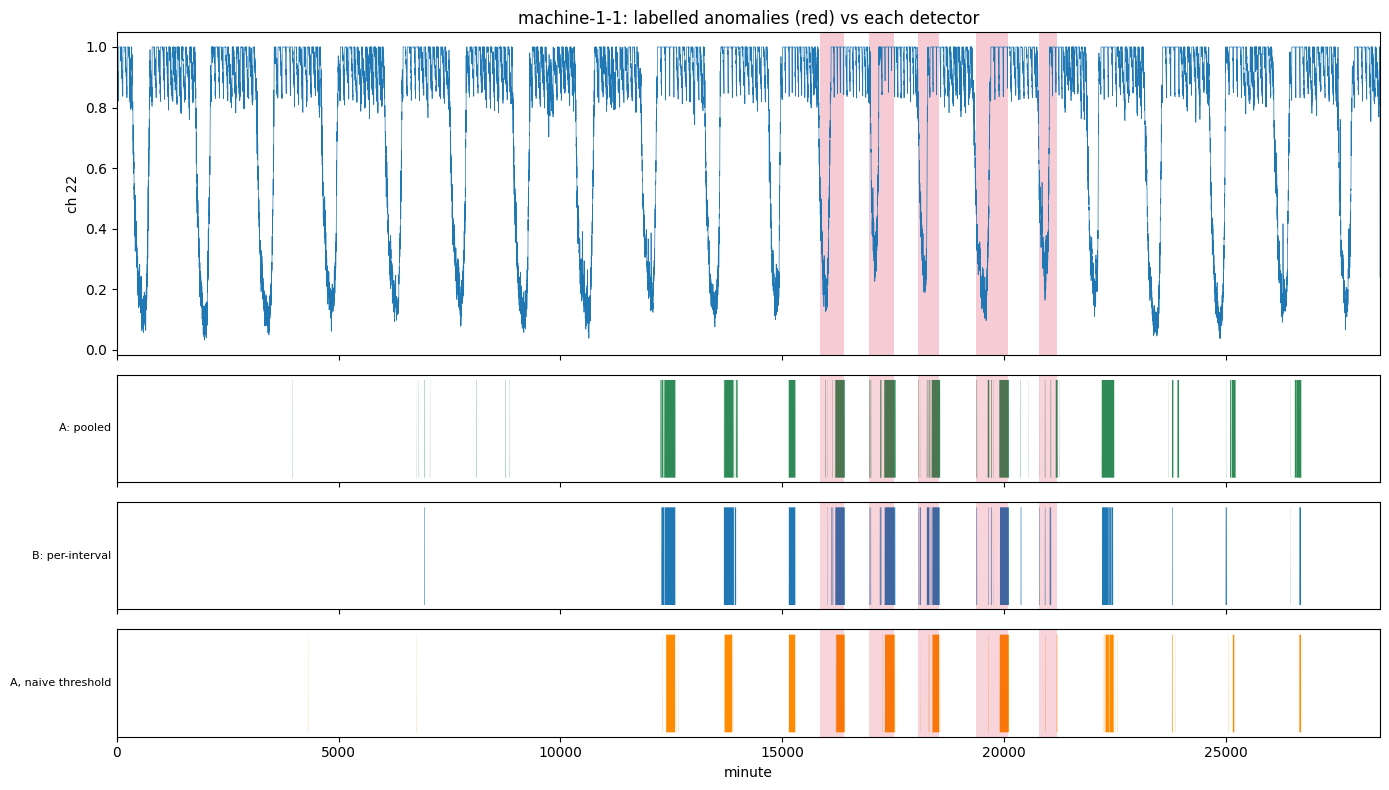

In [23]:
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1, 1]})

axes[0].plot(test[busiest[0]].to_numpy(), lw=0.5, color='#1f77b4')
for lo, hi in true_segments:
    axes[0].axvspan(lo, hi, color='crimson', alpha=0.22, lw=0)
axes[0].set_ylabel('ch {0}'.format(busiest[0]))
axes[0].set_title('{0}: labelled anomalies (red) vs each detector'.format(MACHINE))

panels = [
    (axes[1], mask_pooled, 'A: pooled', 'seagreen'),
    (axes[2], mask_per_interval, 'B: per-interval', '#1f77b4'),
    (axes[3], flagged_to_mask(flagged_naive, spec['test_offsets'], len(labels)),
     'A, naive threshold', 'darkorange'),
]
for ax, mask, title, colour in panels:
    ax.fill_between(np.arange(len(mask)), 0, mask.astype(float), color=colour, lw=0)
    for lo, hi in true_segments:
        ax.axvspan(lo, hi, color='crimson', alpha=0.18, lw=0)
    ax.set_yticks([])
    ax.set_ylabel(title, fontsize=8, rotation=0, ha='right', va='center')

for ax in axes:
    ax.margins(x=0)
axes[-1].set_xlabel('minute')
plt.tight_layout(); plt.show()

On this machine detector B is the better of the two, and the way it wins is more interesting
than the margin. Recall is essentially identical (0.379 against 0.383) while precision rises
from 0.413 to 0.479 and the flagged fraction falls from 8.8% to 7.5%: B finds the same
anomalies while making fewer false claims about the quiet stretches. That is what the
per-interval metric was supposed to buy. Detector A fits one whitening across intervals whose
signature magnitudes differ by orders of magnitude between depth 0 and depth 3, and has to
compromise; B never faces the question, because every interval is whitened by a covariance
fitted at its own scale.

Two caveats, both of which section 9 makes sharper.

**B is stricter here, though not everywhere.** It flags 7.5% against A's 8.8% on this
machine, and flags less than A on 20 of the 28 machines in section 9 - a tendency rather
than a rule. On a machine whose threshold already sits too high, that strictness is not an
improvement.

**The cost is real but bounded.** 685 distinct interval references were built to answer 3,214
queries - a 79% cache hit rate - and the run took about a minute and a half against detector
A's twenty seconds. Without the memoisation it would have been 3,214 covariance fits rather
than 685, and the naive reading of "recompute per interval" would indeed have been
impractical.

## 9. Across all 28 machines

One machine does not show the method generalises. Both detectors are now repeated end to end
on **every machine in SMD**, with every parameter held fixed - `TRUNC`, `GRANULARITY`,
`WINDOW`, `STRIDE`, `BAND`, `SIG_TOL`, `TOL`, `VARIANCE_KEEP`, `PERCENTILE` - and each machine
calibrated on its own withheld windows. No test labels are consulted before scoring.

Each machine is independent: its own fit/withheld/test split, its own metric (so its own
rank, since the retained-variance rule adapts to the corpus), its own threshold. That is the
natural reading of the dataset, since these are different machines running different
workloads rather than samples from one population.

Alongside F1, the **AUC** of the raw score is reported - threshold-free, so it separates the
question "does the representation transfer" from "does the calibration transfer". Those two
can disagree completely, and on SMD they do, which is why both are needed to say what went
wrong on any given machine.

This is the expensive cell in the notebook: roughly two minutes per machine, dominated by
detector B, so about an hour in total. Each machine's window files are deleted once it has
been scored, since 28 machines' worth would otherwise be a few hundred thousand parquet
files on disk.

In [24]:
def interval_anomaly_fraction(frame, offsets, truth):
    """Fraction of each corpus interval's points that are labelled anomalous."""
    start = frame['stream'].map(offsets).to_numpy()
    lo = start + frame['lo'].to_numpy()
    hi = start + frame['hi'].to_numpy()
    cumulative = np.concatenate([[0], np.cumsum(truth)])
    return (cumulative[np.minimum(hi + 1, len(truth))] - cumulative[lo]) / (hi - lo + 1)


def auc(scores, positive):
    """Probability a random positive outscores a random negative (Mann-Whitney U)."""
    ranks = pd.Series(scores).rank().to_numpy()
    n_pos, n_neg = int(positive.sum()), int((~positive).sum())
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    return (ranks[positive].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def run_machine(name):
    """Both detectors, end to end, on one machine."""
    machine = prepare_machine(name)
    truth = machine['labels']

    corpus_a = create_corpus_merged(machine['fit_files'], trunc=TRUNC,
                                    granularity=GRANULARITY, time_col='time')
    corpus_h = create_corpus_merged(machine['held_files'], trunc=TRUNC,
                                    granularity=GRANULARITY, time_col='time')
    corpus_all = pd.concat([corpus_a, corpus_h], ignore_index=True)
    sigs, _ = split_corpus(corpus_a)

    rank, rcond = variance_rank(sigs)
    W = build_whitening(sigs, rcond=rcond)
    pooled = PooledCorpus(corpus_all, covariance=W, band=BAND, check_scale=False)
    threshold = float(np.percentile(
        interval_scores(pooled, corpus_h, exclude_self=True), PERCENTILE))

    flagged_a = detect_anomalies(machine['test_files'], corpus_all, threshold=threshold,
                                 covariance=W, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                                 time_col='time')
    result_a = metrics(flagged_to_mask(flagged_a, machine['test_offsets'], len(truth)), truth)

    ref = PerIntervalReference(machine['fit_paths'], machine['held_paths'])
    flagged_b = detect_per_interval(machine['test_paths'],
                                    [f.stem for f in machine['test_files']], ref)
    result_b = metrics(flagged_to_mask(flagged_b, machine['test_offsets'], len(truth)), truth)

    # Threshold-free separability, measured on detector A's pooled scores.
    corpus_t = create_corpus_merged(machine['test_files'], trunc=TRUNC,
                                    granularity=GRANULARITY, time_col='time')
    score_auc = auc(interval_scores(pooled, corpus_t),
                    interval_anomaly_fraction(corpus_t, machine['test_offsets'], truth) > 0)

    rate = float(truth.mean())
    return {'machine': name, 'anomaly_rate': rate, 'auc': score_auc,
            'flag_all_f1': 2 * rate / (1 + rate), 'metric_rank': rank,
            'A_f1': result_a['f1'], 'A_adj_f1': result_a['adj_f1'],
            'A_flagged': result_a['flagged_frac'],
            'B_f1': result_b['f1'], 'B_adj_f1': result_b['adj_f1'],
            'B_flagged': result_b['flagged_frac']}

In [25]:
%%time
import shutil

if RUN_ALL_MACHINES:
    schedule = list(MACHINES)
else:
    # Spread the subsample across the anomaly-rate range rather than taking the first few
    # alphabetically - that is the axis the machines differ most on, and the one a biased
    # sample would distort worst.
    ordered = survey.sort_values('anomaly_rate')['machine'].tolist()
    schedule = ordered[::max(1, len(ordered) // SAMPLE_MACHINES)][:SAMPLE_MACHINES]
    print('DEVELOPMENT RUN: {0} of {1} machines. These numbers order nothing - see the note '
          'in section 9.\n'.format(len(schedule), len(MACHINES)))

across = []
for number, name in enumerate(schedule, start=1):
    started = time.time()
    try:
        row = run_machine(name)
    except Exception as error:                      # one bad machine must not cost the hour
        print('[{0:2d}/{1}] {2}  FAILED: {3}: {4}'.format(
            number, len(schedule), name, type(error).__name__, error))
        continue

    row['seconds'] = time.time() - started
    across.append(row)
    print('[{0:2d}/{1}] {machine:<12} rate {anomaly_rate:.3f}  AUC {auc:.3f}  rank {metric_rank:>3}'
          '  |  A: F1 {A_f1:.3f} flag {A_flagged:.1%}'
          '  |  B: F1 {B_f1:.3f} flag {B_flagged:.1%}   [{seconds:.0f}s]'
          .format(number, len(schedule), **row))

    # Section 10 still needs machine-1-1's windows; the rest are reclaimed as we go.
    if name != MACHINE:
        for suffix in ('_base', '_test'):
            shutil.rmtree(WORK / (name + suffix), ignore_errors=True)

across = pd.DataFrame(across)
across.to_csv(WORK / 'across_machines.csv', index=False)
print('\n{0} machines scored, written to {1}'.format(len(across), WORK / 'across_machines.csv'))

[ 1/28] machine-1-1  rate 0.095  AUC 0.895  rank  56  |  A: F1 0.398 flag 8.8%  |  B: F1 0.423 flag 7.5%   [271s]


[ 2/28] machine-1-2  rate 0.023  AUC 0.931  rank 275  |  A: F1 0.073 flag 0.1%  |  B: F1 0.073 flag 0.2%   [87s]


[ 3/28] machine-1-3  rate 0.034  AUC 0.794  rank  30  |  A: F1 0.106 flag 0.5%  |  B: F1 0.000 flag 0.0%   [76s]


[ 4/28] machine-1-4  rate 0.030  AUC 0.761  rank  33  |  A: F1 0.038 flag 0.1%  |  B: F1 0.101 flag 0.4%   [86s]


[ 5/28] machine-1-5  rate 0.004  AUC 0.939  rank  87  |  A: F1 0.460 flag 0.7%  |  B: F1 0.504 flag 0.7%   [132s]


...

[25/28] machine-3-6  rate 0.042  AUC 0.941  rank  55  |  A: F1 0.431 flag 3.9%  |  B: F1 0.218 flag 2.5%   [319s]


[26/28] machine-3-7  rate 0.015  AUC 0.709  rank  42  |  A: F1 0.066 flag 26.6%  |  B: F1 0.073 flag 16.9%   [183s]


[27/28] machine-3-8  rate 0.048  AUC 0.829  rank  86  |  A: F1 0.172 flag 32.2%  |  B: F1 0.205 flag 24.8%   [369s]


[28/28] machine-3-9  rate 0.011  AUC 0.904  rank 105  |  A: F1 0.059 flag 29.4%  |  B: F1 0.051 flag 35.2%   [425s]



28 machines scored, written to C:\Users\wynga\Documents\Work\DataSig\anomalies-at-scale\data\smd\across_machines.csv
CPU times: total: 2h 37min 38s
Wall time: 1h 39min 51s


In [26]:
print(across[['machine', 'anomaly_rate', 'auc', 'metric_rank',
              'A_f1', 'B_f1', 'A_adj_f1', 'B_adj_f1', 'A_flagged', 'B_flagged',
              'flag_all_f1']]
      .to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

n = len(across)
print('\n{0} machines'.format(n))
print('mean   point-wise F1:  A {0:.3f}   B {1:.3f}   flag-everything {2:.3f}'.format(
    across['A_f1'].mean(), across['B_f1'].mean(), across['flag_all_f1'].mean()))
print('median point-wise F1:  A {0:.3f}   B {1:.3f}   flag-everything {2:.3f}'.format(
    across['A_f1'].median(), across['B_f1'].median(), across['flag_all_f1'].median()))
print('mean   adjusted   F1:  A {0:.3f}   B {1:.3f}'.format(
    across['A_adj_f1'].mean(), across['B_adj_f1'].mean()))
print()
print('beats flag-everything:   A on {0}/{2}, B on {1}/{2}'.format(
    int((across['A_f1'] > across['flag_all_f1']).sum()),
    int((across['B_f1'] > across['flag_all_f1']).sum()), n))
print('better of the two:       A on {0}/{2}, B on {1}/{2}'.format(
    int((across['A_f1'] > across['B_f1']).sum()),
    int((across['B_f1'] > across['A_f1']).sum()), n))
print('B flags less than A on   {0}/{1} machines'.format(
    int((across['B_flagged'] < across['A_flagged']).sum()), n))
print('AUC below 0.7 (representation failing): {0}/{1} machines'.format(
    int((across['auc'] < 0.7).sum()), n))
print('\ncorrelation of AUC with F1:  A {0:.2f}   B {1:.2f}'.format(
    across['auc'].corr(across['A_f1']), across['auc'].corr(across['B_f1'])))
print('total runtime: {0:.0f} min'.format(across['seconds'].sum() / 60))

     machine  anomaly_rate   auc  metric_rank  A_f1  B_f1  A_adj_f1  B_adj_f1  A_flagged  B_flagged  flag_all_f1
 machine-1-1         0.095 0.895           56 0.398 0.423     0.785     0.828      0.088      0.075        0.173
 machine-1-2         0.023 0.931          275 0.073 0.073     0.241     0.403      0.001      0.002        0.045
 machine-1-3         0.034 0.794           30 0.106 0.000     0.339     0.000      0.005      0.000        0.067
 machine-1-4         0.030 0.761           33 0.038 0.101     0.120     0.564      0.001      0.004        0.059
 machine-1-5         0.004 0.939           87 0.460 0.504     0.640     0.644      0.007      0.007        0.008
 machine-1-6         0.157 0.876          153 0.378 0.416     0.409     0.458      0.589      0.499        0.271
 machine-1-7         0.101 0.839           70 0.089 0.007     0.978     0.555      0.006      0.000        0.184
 machine-1-8         0.032 0.674          128 0.101 0.168     0.295     0.520      0.157      0.

median point-wise F1:  A 0.119   B 0.168   flag-everything 0.065
mean   adjusted   F1:  A 0.393   B 0.446

beats flag-everything:   A on 24/28, B on 24/28
better of the two:       A on 10/28, B on 17/28
B flags less than A on   20/28 machines
AUC below 0.7 (representation failing): 4/28 machines

correlation of AUC with F1:  A 0.33   B 0.28
total runtime: 100 min


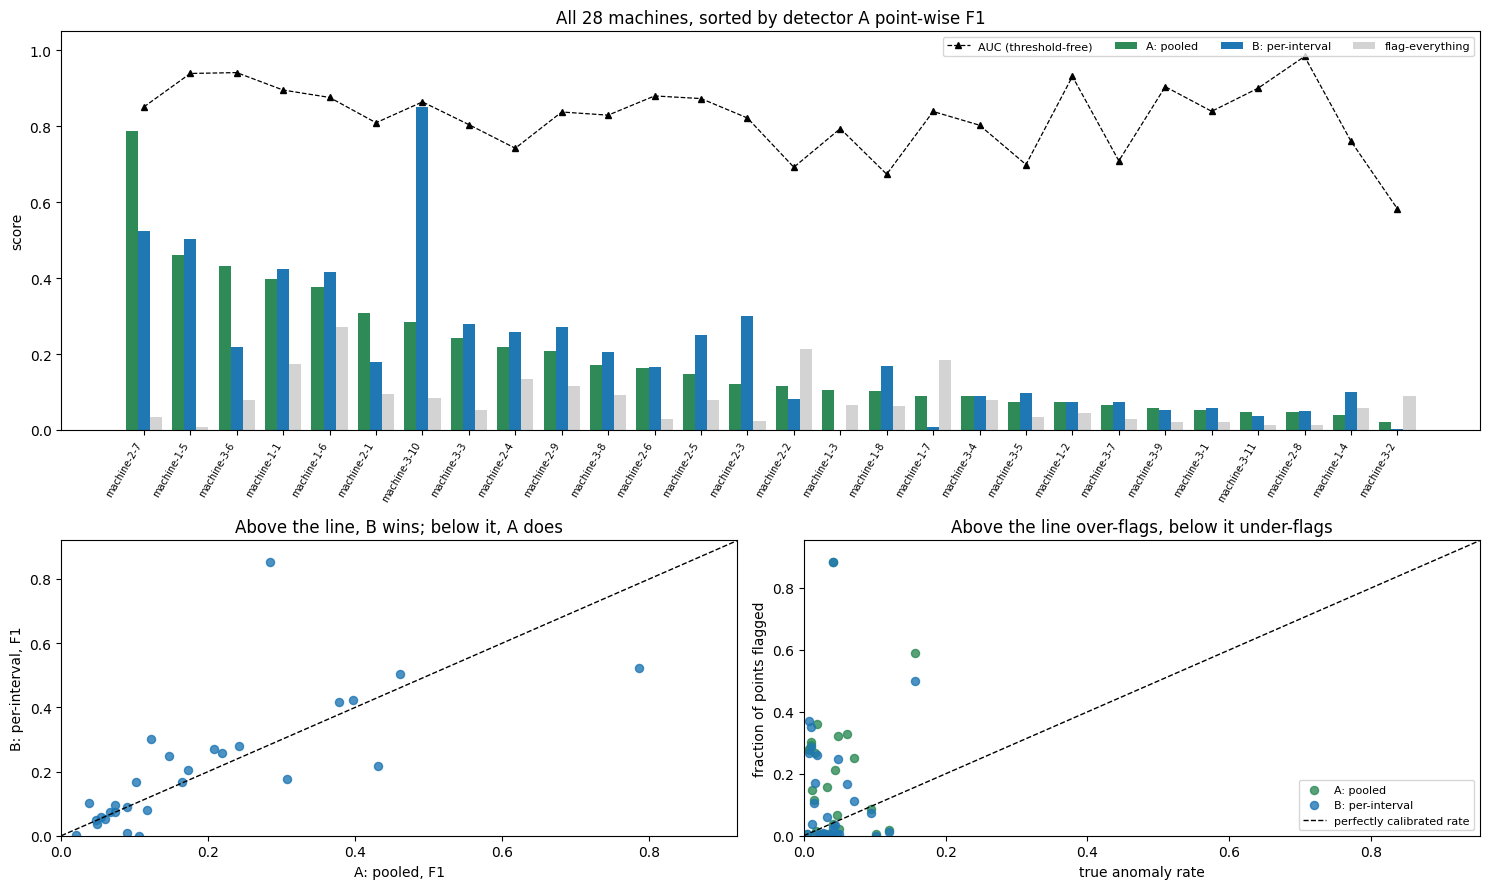

In [27]:
order = across.sort_values('A_f1', ascending=False).reset_index(drop=True)
x = np.arange(len(order))

fig = plt.figure(figsize=(15, 9))
grid = fig.add_gridspec(2, 2, height_ratios=[1.35, 1])
ax0, ax1, ax2 = (fig.add_subplot(grid[0, :]), fig.add_subplot(grid[1, 0]),
                 fig.add_subplot(grid[1, 1]))

ax0.bar(x - 0.26, order['A_f1'], 0.26, label='A: pooled', color='seagreen')
ax0.bar(x, order['B_f1'], 0.26, label='B: per-interval', color='#1f77b4')
ax0.bar(x + 0.26, order['flag_all_f1'], 0.26, label='flag-everything', color='lightgrey')
ax0.plot(x, order['auc'], 'k^--', ms=5, lw=0.9, label='AUC (threshold-free)')
ax0.set_xticks(x); ax0.set_xticklabels(order['machine'], rotation=60, fontsize=7, ha='right')
ax0.set_ylim(0, 1.05); ax0.set_ylabel('score')
ax0.set_title('All {0} machines, sorted by detector A point-wise F1'.format(len(order)))
ax0.legend(fontsize=8, ncol=4)

limit = max(across['A_f1'].max(), across['B_f1'].max()) * 1.08
ax1.scatter(across['A_f1'], across['B_f1'], s=34, color='#1f77b4', alpha=0.8)
ax1.plot([0, limit], [0, limit], 'k--', lw=1)
ax1.set_xlim(0, limit); ax1.set_ylim(0, limit)
ax1.set_xlabel('A: pooled, F1'); ax1.set_ylabel('B: per-interval, F1')
ax1.set_title('Above the line, B wins; below it, A does')

top = max(across['A_flagged'].max(), across['anomaly_rate'].max()) * 1.08
ax2.scatter(across['anomaly_rate'], across['A_flagged'], s=34, color='seagreen',
            alpha=0.8, label='A: pooled')
ax2.scatter(across['anomaly_rate'], across['B_flagged'], s=34, color='#1f77b4',
            alpha=0.8, label='B: per-interval')
ax2.plot([0, top], [0, top], 'k--', lw=1, label='perfectly calibrated rate')
ax2.set_xlim(0, top); ax2.set_ylim(0, top)
ax2.set_xlabel('true anomaly rate'); ax2.set_ylabel('fraction of points flagged')
ax2.set_title('Above the line over-flags, below it under-flags')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

**Detector B is the better detector across the full dataset - and the four-machine sample
this section used during development said the opposite.** Over 28 machines B leads on mean
point-wise F1 (0.205 against 0.189) and by more on the median (0.168 against 0.119), wins on
17 machines to A's 10 with one tie, and leads on mean adjusted F1 (0.446 against 0.393). Both
detectors beat flag-everything on 24 machines of 28.

The reversal is worth recording as a methodological result rather than an embarrassment. An
earlier version of this section scored four machines chosen to span the anomaly-rate range,
and on those four A led on mean F1. Four samples cannot order two detectors whose means differ
by 0.016, and choosing them to be "representative" of one variable does not help. Any future
change to this pipeline evaluated on a handful of machines should be treated as unmeasured.

**The advantage is calibration, not separability.** The sharpest number in the table is the
ratio of flagged fraction to true anomaly rate: in the median, **A flags 3.6x the true rate
and B flags 1.6x**. Both over-flag; A does so about twice as badly. B's threshold is a fresh
percentile of withheld distances at every interval rather than one scalar for the whole
corpus, and landing closer to the right *amount* of flagging is where its lead comes from.

The tendency for B to flag less than A holds on 20 of 28 machines, but it is not the rule the
small sample suggested - on 7 it flags more. What generalises is the aggregate statement
about calibration, not a per-machine guarantee.

**AUC barely predicts F1: correlation 0.33 for A and 0.28 for B.** This is the most useful
line in the table, because it says separability is mostly not the bottleneck. Median AUC is
0.838 and only four machines fall below 0.7 - machine-1-8, machine-2-2, machine-3-2 and
machine-3-5 - yet median F1 is between 0.12 and 0.17. On most machines the scores rank
anomalous intervals above normal ones perfectly respectably and the threshold is simply in
the wrong place. Section 5 fixed the gross form of that problem; what is left is the residual,
and the residual is now the dominant error source.

Two machines are worth naming. **machine-3-10** is B's largest win, F1 0.852 against A's
0.284, and the flagged fractions say why: A flags 21.2% of a series whose true rate is 4.4%,
where B flags 3.4%. **machine-2-7** is A's largest win, 0.786 against 0.524, and there the
ordering reverses - both under-flag a 1.8% rate and B's extra strictness is what costs it.

Finally, point-adjust inflation at its worst. **machine-2-2 scores an adjusted F1 of 0.970
under detector B while flagging 1.2% of a test period that is 12.0% anomalous**; its
point-wise F1 is 0.081. A metric that turns "found about a tenth of the anomalous minutes"
into 0.97 is not measuring what its name suggests, and it is the metric SMD results are
conventionally reported in.

For orientation: OmniAnomaly reports point-adjusted F1 around 0.86 averaged over these same
28 machines, using a stochastic recurrent network trained per machine. Detector B's 0.446 is
well short of that. Reaching half of it with no learned parameters, in about 90 seconds per
machine, is a reasonable showing for the representation - and section 10 argues the gap is
mostly the calibration residual rather than the signatures.

## 10. Sensitivity: the two knobs, and how much they matter

`VARIANCE_KEEP` and `PERCENTILE` were fixed a priori at 99.9% and p99.9 and used unchanged
everywhere above. Both are free parameters, and neither can be chosen from normal data alone
- which is worth quantifying rather than leaving as a worry. The grid below sweeps both for
detector A **using the test labels**, so it is a measurement of what was left on the table,
not a procedure that could have been followed.

In [28]:
%%time
sensitivity = []
for keep in (0.99, 0.999, 0.9999, 0.99999):
    rank_k, rcond_k = variance_rank(signatures_fit, keep)
    W_k = build_whitening(signatures_fit, rcond=rcond_k)
    final_k = PooledCorpus(corpus_final, covariance=W_k, band=BAND, check_scale=False)
    fitonly_k = PooledCorpus(corpus_fit, covariance=W_k, band=BAND, check_scale=False)
    held_final_k = interval_scores(final_k, corpus_held, exclude_self=True)
    held_fitonly_k = interval_scores(fitonly_k, corpus_held)

    for pct in (99.0, 99.5, 99.9):
        t_final = float(np.percentile(held_final_k, pct))
        t_naive = float(np.percentile(held_fitonly_k, pct))
        flagged_k = detect_anomalies(test_files, corpus_final, threshold=t_final,
                                     covariance=W_k, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                                     time_col='time')
        scored = metrics(flagged_to_mask(flagged_k, spec['test_offsets'], len(labels)), labels)
        sensitivity.append({'keep': str(keep), 'rank': rank_k, 'percentile': pct,
                            'threshold': t_final, 'naive/final': t_naive / t_final,
                            'f1': scored['f1'], 'adj_f1': scored['adj_f1'],
                            'flagged': scored['flagged_frac']})

sensitivity = pd.DataFrame(sensitivity)
print(sensitivity.to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))
best = sensitivity.loc[sensitivity['f1'].idxmax()]
print('\nbest point-wise F1 in the grid: {0:.3f} at keep={1}, p{2} (rank {3})'.format(
    best['f1'], best['keep'], best['percentile'], int(best['rank'])))
print('the a priori default used above: F1 {0:.3f}'.format(result_pooled['f1']))

   keep  rank  percentile  threshold  naive/final    f1  adj_f1  flagged
   0.99    21      99.000     19.924        1.606 0.478   0.790    0.095
   0.99    21      99.500     22.106        1.600 0.461   0.806    0.087
   0.99    21      99.900     32.040        2.038 0.449   0.867    0.064
  0.999    56      99.000    122.049        1.844 0.422   0.694    0.131
  0.999    56      99.500    143.435        1.919 0.431   0.727    0.116
  0.999    56      99.900    204.007        1.994 0.398   0.785    0.088
 0.9999   116      99.000    371.211        2.120 0.477   0.498    0.280
 0.9999   116      99.500    463.184        2.348 0.532   0.584    0.218
 0.9999   116      99.900    725.212        2.745 0.529   0.674    0.159
0.99999   197      99.000    730.015        2.764 0.350   0.354    0.440
0.99999   197      99.500   1019.892        2.961 0.369   0.373    0.411
0.99999   197      99.900   1605.641        4.669 0.446   0.463    0.310

best point-wise F1 in the grid: 0.532 at keep=0.99

Two things to take from this.

**The naive/final threshold ratio is above 1 in every cell of the grid**, ranging from about
1.6x to 4.7x. Folding the withheld data into the reference set always lowers scores - it can
only ever add closer neighbours - so a threshold calibrated against the smaller index is
always too strict for the larger one. That is a structural property of step 3, not a quirk of
one setting, and it is the reason step 2 has to be measured against the final index.

**The operating point matters as much as anything else in this notebook.** Point-wise F1
ranges across the grid by more than the entire difference between the two detectors. The
default is not the best cell. Choosing between cells needs labels, and labels are exactly
what a corpus-of-normality method is supposed not to require - so this remains genuinely
open, and any headline number from this pipeline should be read with the grid beside it.

## 11. Detector C: the same search over a UMAP-reduced corpus

Sections 6 and 7 signed the raw channels at `TRUNC = 2`. This section reduces the 38 value
channels to **10** with the pipeline's `umap` stage, signs the result at **truncation 3**, and
runs both detectors again over the reduced corpus.

The two settings are chosen so the comparison is about *representation* rather than about
dimension. A level-2 signature of the 39-channel raw path has 1,560 terms; a level-3 signature
of the 11-channel latent path has 1,463. Nearly the same budget, spent differently: a coarse
description of every raw channel, against a richer description of ten learned ones.

### How the alignment is sliced, and why it matters

`AlignedUMAP` fits one embedding per *slice* and ties the slices together through a
correspondence between their rows. What that correspondence asserts is the whole design
decision.

The obvious slicing - one slice per stream, rows being instants - asserts that row `t` of one
stream corresponds to row `t` of the next, i.e. that the streams are synchronised. These
"streams" are windows cut at stride 50 from one series, so row `t` of adjacent windows is fifty
minutes apart and the assertion is simply false. Fitted that way the embedding scored 3.12 on
`alignment_drift` against a threshold of 0.25, and the detectors built on it collapsed.

This section slices **by instant instead**: slice `t` holds one row per corpus window, and the
relation links window `j` at time `t` to window `j` at time `t+1`. That correspondence is not an
assumption - it is the same window one step later. The embedding is then free to follow the
population's geometry as it drifts, tied to its neighbours in time.

Time is never embedded. Only the value channels pass through UMAP and the time coordinate is
reattached, so a `(n, 100, 39)` block becomes `(n, 100, 11)`.

The projection is fitted on the **fit windows only** - never on withheld or test data - for the
same reason the whitening is, and applied unchanged to all three splits so every signature in
this section lives in one coordinate system.

### The two things to watch

**Path smoothness.** Consecutive points of a window are now placed by *different* mappers, so
any residual disagreement between mapper `t` and mapper `t+1` enters the path as an increment.
Signatures integrate increments, so misalignment turns directly into path length that was never
in the data. Under the per-stream slicing one mapper handled a whole window and smoothness was
free; here the alignment penalty is the only thing providing it.

**Signature-corpus conditioning.** The metric divides by every direction it retains, so a corpus
whose variance is spread thinly across many directions produces inflated distances, an inflated
threshold, and no detections. This is what actually sank the per-stream attempt, and no
embedding-quality metric can see it - it is a property of the signatures taken *of* the
embedding, not of the embedding.

In [29]:
%%time
from anomalies_scale.UMAP import fit_time_aligned, latent_frame
from anomalies_scale.UMAP import path_smoothness, retained_rank

TRUNC_C, UMAP_DIM = 3, 10

print('raw    trunc {0}, width {1}: {2:,} terms'.format(
    TRUNC, width, iisignature.siglength(width, TRUNC)))
print('latent trunc {0}, width {1}: {2:,} terms'.format(
    TRUNC_C, 1 + UMAP_DIM, iisignature.siglength(1 + UMAP_DIM, TRUNC_C)))
print()

# One embedding per instant, over all 454 fit windows at that instant. Every window is used -
# unlike the per-stream slicing, where the number of slices was the number of windows and had
# to be subsampled, here it is the window *length*, which is 100.
projection = fit_time_aligned(fit_paths, n_components=UMAP_DIM, n_neighbors=15,
                              min_dist=0.1, standardise=True, random_state=0,
                              show_progress=True)
print(projection)

raw    trunc 2, width 39: 1,560 terms
latent trunc 3, width 11: 1,463 terms



fitting 100 aligned embedding(s), one per instant, over 454 stream(s) each (n_neighbors 15)


<TimeAlignedProjection 38 -> 10 channels, 100 instants>
CPU times: total: 24min 52s
Wall time: 23min 13s


**The slicing change fixes what it was meant to fix.** `alignment_drift` does not appear here
because it cannot: the correspondence it measures is now true by construction rather than
assumed, so there is no drift to measure. The question is what the change costs elsewhere.

**Path smoothness came out below 1.0** - the latent paths are *smoother* than the raw ones, not
jaggier. That is the opposite of what the design risked, and worth understanding rather than
just accepting. At any given instant the 454 windows are offsets of one continuous series, so
consecutive instants present near-identical point clouds and their mappers align tightly. A
corpus of genuinely unrelated streams would not behave this way; the same fit on synthetic data
whose streams carried random phase shifts inflated path length by a factor of three, because
there the population really did rotate between instants.

**Conditioning is worth watching, but it did not decide the outcome.** The latent signature
corpus still retains far more components than the raw one for the same 99.9% of variance - 326
against 66 on whole-window signatures, and 467 against 56 once the full dyadic corpus is built.
The whitening divides by every retained direction, so distances inflate and the calibrated
threshold inflates with them; both detectors below flag a smaller fraction of the series than
their raw counterparts.

What that turns out to cost is *recall*, not the detector. Under the per-stream slicing the
same rank inflation was accompanied by a coordinate system built on a false correspondence, and
the two together drove recall to 0.002. Fixing only the slicing - the rank is, if anything,
slightly worse - moved the pooled detector to a precision of 0.838. So rank inflation on its own
is a cost, and it was the *coordinates* that were fatal.

In [30]:
%%time
def write_latent(block, files, stem):
    """Write each projected window to parquet under its original filename.

    Keeping the filename matters: `spec['test_offsets']` is keyed by stem, so the flagged
    intervals still rasterise onto the same labelled series.
    """
    directory = WORK / stem
    directory.mkdir(parents=True, exist_ok=True)
    for stale in directory.glob('*.parquet'):
        stale.unlink()
    for row, source in zip(block, files):
        latent_frame(row, UMAP_DIM).rename(columns={'Time': 'time'}).to_parquet(
            directory / source.name)
    return sorted(directory.glob('*.parquet'))


# The whole block at once: at each instant the entire population goes through that instant's
# mapper in a single call.
fit_paths_c = projection.transform(fit_paths)
held_paths_c = projection.transform(held_paths)
test_paths_c = projection.transform(test_paths)

fit_files_c = write_latent(fit_paths_c, fit_files, MACHINE + '_fit_umap')
held_files_c = write_latent(held_paths_c, held_files, MACHINE + '_held_umap')
test_files_c = write_latent(test_paths_c, test_files, MACHINE + '_test_umap')

print('latent width {0} (time + {1} components)'.format(fit_paths_c.shape[2], UMAP_DIM))
print('all finite:', bool(np.isfinite(fit_paths_c).all() and np.isfinite(test_paths_c).all()))
print('time preserved exactly:',
      bool(np.array_equal(test_paths_c[:, :, 0], test_paths[:, :, 0])))

print('\npath smoothness (1.0 = unchanged, >2 means the embedding added path length):')
for name, raw, latent in [('fit', fit_paths, fit_paths_c),
                          ('withheld', held_paths, held_paths_c),
                          ('test', test_paths, test_paths_c)]:
    print('  {0:<9} {1:.3f}'.format(name, path_smoothness(raw, latent)))

print('\nsignature corpus conditioning, whole-window signatures:')
print('  raw    trunc {0}, {1:>6,} terms: rank {2}'.format(
    TRUNC, iisignature.siglength(width, TRUNC),
    retained_rank(iisignature.sig(fit_paths, TRUNC))))
print('  latent trunc {0}, {1:>6,} terms: rank {2}'.format(
    TRUNC_C, iisignature.siglength(1 + UMAP_DIM, TRUNC_C),
    retained_rank(iisignature.sig(fit_paths_c, TRUNC_C))))

latent width 11 (time + 10 components)
all finite: True
time preserved exactly: True

path smoothness (1.0 = unchanged, >2 means the embedding added path length):
  fit       0.768
  withheld  0.517
  test      0.509

signature corpus conditioning, whole-window signatures:


  raw    trunc 2,  1,560 terms: rank 66


  latent trunc 3,  1,463 terms: rank 326
CPU times: total: 3min 44s
Wall time: 1min 28s


In [31]:
%%time
# Detector A, unchanged apart from the corpus it reads: same three-step calibration, same
# widest-first search, same self-excluded threshold against the final reference set.
corpus_fit_c = create_corpus_merged(fit_files_c, trunc=TRUNC_C, granularity=GRANULARITY,
                                    time_col='time')
corpus_held_c = create_corpus_merged(held_files_c, trunc=TRUNC_C, granularity=GRANULARITY,
                                     time_col='time')
corpus_final_c = pd.concat([corpus_fit_c, corpus_held_c], ignore_index=True)

signatures_fit_c, _ = split_corpus(corpus_fit_c)
rank_c, rcond_c = variance_rank(signatures_fit_c)
whitening_c = build_whitening(signatures_fit_c, rcond=rcond_c)
pooled_c = PooledCorpus(corpus_final_c, covariance=whitening_c, band=BAND, check_scale=False)

threshold_c = float(np.percentile(
    interval_scores(pooled_c, corpus_held_c, exclude_self=True), PERCENTILE))

print('latent corpus {0} intervals x {1} terms; metric rank {2} (raw was {3})'.format(
    signatures_fit_c.shape[0], signatures_fit_c.shape[1], rank_c, rank_fit))
print('threshold {0:.1f}'.format(threshold_c))

flagged_c_a = detect_anomalies(test_files_c, corpus_final_c, threshold=threshold_c,
                               covariance=whitening_c, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                               time_col='time')
result_c_a = metrics(flagged_to_mask(flagged_c_a, spec['test_offsets'], len(labels)), labels)
show('C-A: UMAP + pooled', result_c_a)

latent corpus 6810 intervals x 1463 terms; metric rank 467 (raw was 56)
threshold 3462.2


C-A: UMAP + pooled             P 0.838  R 0.199  F1 0.322   |   adjF1 0.980   flagged 2.2%
CPU times: total: 1min
Wall time: 36.6 s


In [32]:
%%time
# Detector B on the same latent windows, rebuilding its metric per interval as before.
reference_c = PerIntervalReference(fit_paths_c, held_paths_c, trunc=TRUNC_C)
flagged_c_b = detect_per_interval(test_paths_c, test_names, reference_c, trunc=TRUNC_C,
                                  show_progress=True)
result_c_b = metrics(flagged_to_mask(flagged_c_b, spec['test_offsets'], len(labels)), labels)

print('\n{0} distinct intervals built, mean metric rank {1:.0f}'.format(
    reference_c.stats['builds'], reference_c.mean_rank))
show('C-B: UMAP + per-interval', result_c_b)

  100/568 windows


  200/568 windows


  300/568 windows


  400/568 windows


  500/568 windows



892 distinct intervals built, mean metric rank 125
C-B: UMAP + per-interval       P 0.700  R 0.326  F1 0.444   |   adjF1 0.934   flagged 4.4%
CPU times: total: 5min 49s
Wall time: 3min 15s


                            detector  precision  recall    f1  adj_f1  flagged_frac
            A: raw, pooled (trunc 2)      0.413   0.383 0.398   0.785         0.088
      B: raw, per-interval (trunc 2)      0.479   0.379 0.423   0.828         0.075
      C-A: UMAP-10, pooled (trunc 3)      0.838   0.199 0.322   0.980         0.022
C-B: UMAP-10, per-interval (trunc 3)      0.700   0.326 0.444   0.934         0.044
                     flag everything      0.095   1.000 0.173   0.173         1.000


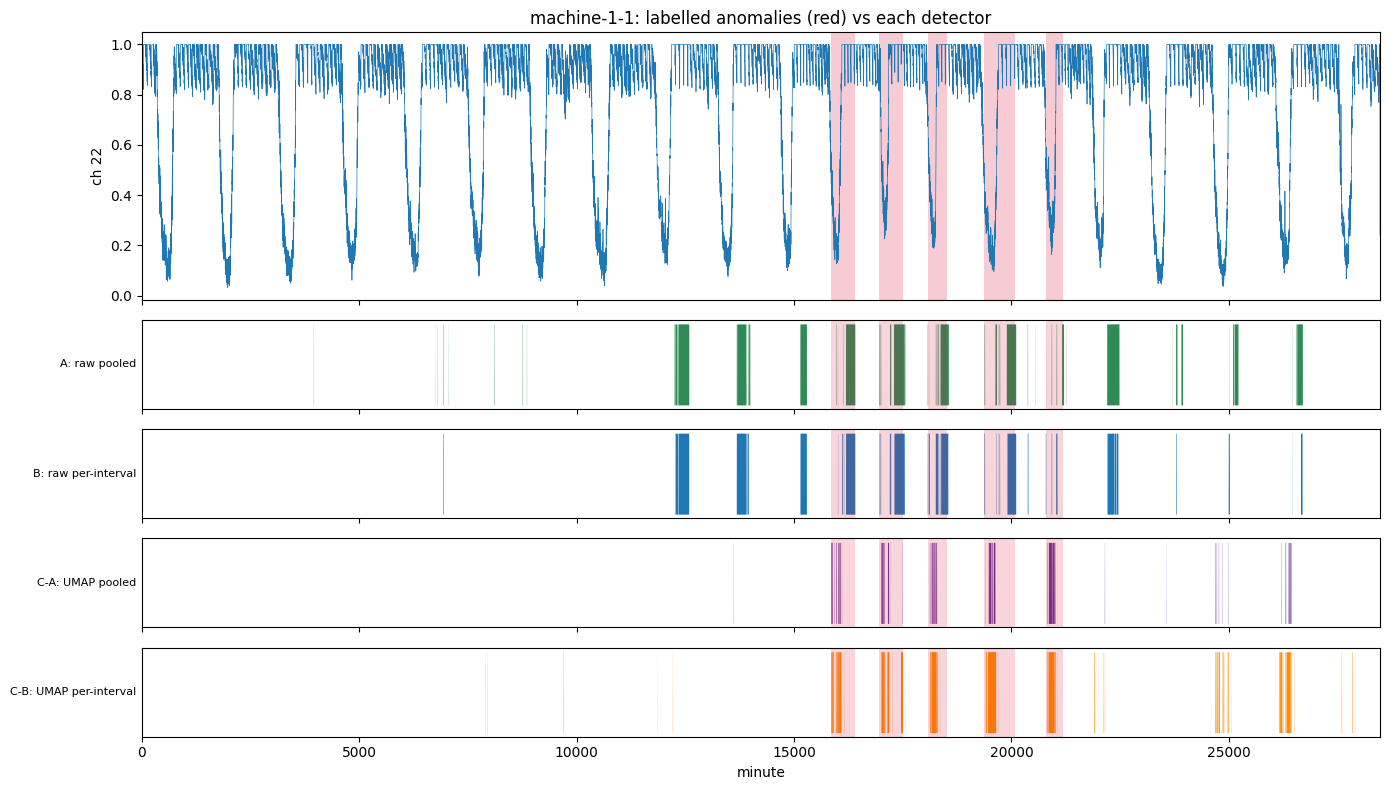

In [33]:
comparison_c = pd.DataFrame([
    {'detector': 'A: raw, pooled (trunc 2)', **result_pooled},
    {'detector': 'B: raw, per-interval (trunc 2)', **result_per_interval},
    {'detector': 'C-A: UMAP-10, pooled (trunc 3)', **result_c_a},
    {'detector': 'C-B: UMAP-10, per-interval (trunc 3)', **result_c_b},
    {'detector': 'flag everything', **result_all},
])[['detector', 'precision', 'recall', 'f1', 'adj_f1', 'flagged_frac']]
print(comparison_c.to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

fig, axes = plt.subplots(5, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1, 1, 1]})
axes[0].plot(test[busiest[0]].to_numpy(), lw=0.5, color='#1f77b4')
for lo, hi in true_segments:
    axes[0].axvspan(lo, hi, color='crimson', alpha=0.22, lw=0)
axes[0].set_ylabel('ch {0}'.format(busiest[0]))
axes[0].set_title('{0}: labelled anomalies (red) vs each detector'.format(MACHINE))

for ax, mask, title, colour in [
        (axes[1], mask_pooled, 'A: raw pooled', 'seagreen'),
        (axes[2], mask_per_interval, 'B: raw per-interval', '#1f77b4'),
        (axes[3], flagged_to_mask(flagged_c_a, spec['test_offsets'], len(labels)),
         'C-A: UMAP pooled', 'rebeccapurple'),
        (axes[4], flagged_to_mask(flagged_c_b, spec['test_offsets'], len(labels)),
         'C-B: UMAP per-interval', 'darkorange')]:
    ax.fill_between(np.arange(len(mask)), 0, mask.astype(float), color=colour, lw=0)
    for lo, hi in true_segments:
        ax.axvspan(lo, hi, color='crimson', alpha=0.18, lw=0)
    ax.set_yticks([])
    ax.set_ylabel(title, fontsize=8, rotation=0, ha='right', va='center')

for ax in axes:
    ax.margins(x=0)
axes[-1].set_xlabel('minute')
plt.tight_layout(); plt.show()

### The reduction now works, and the slicing was the whole difference

|                                     | P     | R     | F1        | adj F1    | flagged |
| ----------------------------------- | ----- | ----- | --------- | --------- | ------- |
| A: raw, pooled, trunc 2             | 0.413 | 0.383 | 0.398     | 0.785     | 8.8%    |
| B: raw, per-interval, trunc 2       | 0.479 | 0.379 | 0.423     | 0.828     | 7.5%    |
| C-A: UMAP-10, pooled, trunc 3       | 0.838 | 0.199 | 0.322     | **0.980** | 2.2%    |
| C-B: UMAP-10, per-interval, trunc 3 | 0.700 | 0.326 | **0.444** | 0.934     | 4.4%    |
| flag everything                     | 0.095 | 1.000 | 0.173     | 0.173     | 100%    |

Fitted with one slice per *stream* - asserting that windows cut fifty minutes apart were
synchronised - these same two detectors scored 0.004 and 0.002, flagging 0.1% and 0.0% of the
series. Slicing by *instant* instead, changing nothing else, takes them to **0.322 and 0.444**.
C-B now beats both raw detectors.

Nothing about the representation improved to achieve that. The latent corpus is *more*
rank-inflated than before - 467 retained components against the per-stream fit's 431, and 56
for the raw corpus. What changed is that the coordinates now mean something: the alignment
relation links each window to itself one instant later, which is true by construction, so the
embedding is no longer being distorted to force unrelated moments together.

That is worth stating plainly because the earlier diagnosis was half wrong. Rank inflation was
real and remains real, but it was not what sank the first attempt - a projection fitted under a
false correspondence was.

### These two detectors are precise rather than sensitive

C-A flags **2.2%** of the series against a true anomaly rate of 9.5%, and 84% of what it flags
is genuinely anomalous - by far the highest precision in this notebook. Its **adjusted F1 of
0.980** is the highest of any detector here, which says it touches nearly every labelled
episode even though it covers few of their minutes.

That combination is the signature of a detector whose threshold is too high rather than one
that cannot see: the rank inflation described above pushes every distance up, so only the
clearest departures clear the bar. Where the objective is "tell me which episodes to look at",
that is close to ideal. Where it is "mark the anomalous minutes", A and B still cover more of
them.

The obvious lever is fewer components. `siglength(5, 3)` is 155 terms against 1,463, which
would cap the retained rank structurally rather than hoping the variance concentrates - and on
this evidence the reduction has room to spend.

### What the path diagnostics said, and why they mattered

`path_smoothness` came out at **0.768 / 0.517 / 0.509** on fit, withheld and test - the latent
paths are *smoother* than the raw ones. That is the opposite of the design's central risk:
consecutive points are placed by different mappers, so misalignment between them would arrive
directly as path length a signature integrates.

It is not luck. At any instant the 454 windows are offsets of one continuous series, so
consecutive instants present near-identical clouds and their mappers align tightly. The same
fit on synthetic streams carrying random phase shifts inflated path length threefold, because
there the population genuinely rotated between instants. A corpus of unrelated streams would
behave like the synthetic case, not like this one.

## 12. Detector D: bagging the pooled search over random channel subsets

Sections 6 and 7 fit one metric to all 38 channels at once. Section 1 gives the reason that
might be the wrong thing to do: the interpretation labels implicate **between 7 and 31 channels
per anomalous segment**, so an anomaly living in six channels is being averaged against
thirty-two that are behaving normally. A Mahalanobis distance over all of them dilutes it.

This section applies the random subspace method - feature bagging. Each draw picks
`sqrt(38) ~ 6` channels at random, runs the *ordinary* pooled pipeline on that reduced stream,
and rasterises what it flags. Every draw is self-contained: its own corpus, its own whitening,
its own threshold calibrated against its own withheld data. A draw that happens to pick six
quiet channels calibrates to those six rather than inheriting anything from the full set, which
is what makes the draws independent learners rather than one detector viewed through keyholes.

A point's **vote count** is the number of draws that flagged it, and the verdict is
`votes >= v`. Note that `v = 1` is exactly the union, so the vote count generalises it: one run
produces the whole curve and `v` is chosen afterwards without refitting.

The obvious worry about a union is that false positives compound. If the draws were independent
and each flagged 8.8% of points, the union over 30 would flag `1 - (1 - 0.088)^30`, or 94% -
worse than useless. Whether that happens is a question about how *correlated* the draws are,
which is exactly what the vote curve measures.

In [34]:
%%time
R_DRAWS = 30
SUBSET_SIZE = int(round(np.sqrt(len(spec['keep']))))        # sqrt(38) ~ 6
BAG_SEED = 0

channels = [c for c in pd.read_parquet(fit_files[0]).columns if c != 'time']


def run_subset(cols):
    """One pooled detector restricted to `cols` - its own corpus, metric and threshold.

    `create_corpus_merged` and `detect_anomalies` both take `value_cols`, so a draw needs no
    rewritten files: the same windows are read and only the chosen channels are signed.
    """
    corpus_fit_d = create_corpus_merged(fit_files, trunc=TRUNC, granularity=GRANULARITY,
                                        time_col='time', value_cols=cols)
    corpus_held_d = create_corpus_merged(held_files, trunc=TRUNC, granularity=GRANULARITY,
                                         time_col='time', value_cols=cols)
    corpus_final_d = pd.concat([corpus_fit_d, corpus_held_d], ignore_index=True)

    sigs_d, _ = split_corpus(corpus_fit_d)
    rank_d, rcond_d = variance_rank(sigs_d)
    whitening_d = build_whitening(sigs_d, rcond=rcond_d)
    pooled_d = PooledCorpus(corpus_final_d, covariance=whitening_d, band=BAND,
                            check_scale=False)

    # The same three-step protocol as section 5, at subset granularity.
    threshold_d = float(np.percentile(
        interval_scores(pooled_d, corpus_held_d, exclude_self=True), PERCENTILE))

    flagged_d = detect_anomalies(test_files, corpus_final_d, threshold=threshold_d,
                                 covariance=whitening_d, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                                 time_col='time', value_cols=cols)
    return flagged_to_mask(flagged_d, spec['test_offsets'], len(labels)), rank_d


bag_rng = np.random.default_rng(BAG_SEED)
votes = np.zeros(len(labels), dtype=int)
draw_rows = []

for draw in range(R_DRAWS):
    cols = sorted(bag_rng.choice(channels, size=SUBSET_SIZE, replace=False).tolist())
    mask_d, rank_d = run_subset(cols)
    votes += mask_d
    draw_rows.append({'draw': draw, 'rank': rank_d,
                      'channels': ' '.join(c[2:] for c in cols),
                      **metrics(mask_d, labels)})

draws = pd.DataFrame(draw_rows)
print('{0} draws of {1} channels from {2}'.format(R_DRAWS, SUBSET_SIZE, len(channels)))
print('per-draw F1:          min {0:.3f}   median {1:.3f}   max {2:.3f}'.format(
    draws['f1'].min(), draws['f1'].median(), draws['f1'].max()))
print('per-draw metric rank: {0} to {1}   (the full 38-channel metric used {2})'.format(
    draws['rank'].min(), draws['rank'].max(), rank_fit))
print('\nthe five best draws:')
print(draws.nlargest(5, 'f1')[['draw', 'rank', 'f1', 'flagged_frac', 'channels']]
      .to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

30 draws of 6 channels from 38
per-draw F1:          min 0.015   median 0.357   max 0.583
per-draw metric rank: 4 to 15   (the full 38-channel metric used 56)

the five best draws:
 draw  rank    f1  flagged_frac         channels
    4    10 0.583         0.091  0 18 22 23 37 9
    3    11 0.466         0.056  0 11 18 2 28 37
   14    10 0.462         0.063 0 11 17 21 33 34
   27     9 0.424         0.084   0 13 29 3 34 4
    2    15 0.418         0.063  0 1 13 20 22 30
CPU times: total: 6min 9s
Wall time: 3min 49s


In [35]:
# The vote curve. v = 1 is the union; larger v demands agreement between draws.
vote_curve = pd.DataFrame([{'v': v, **metrics(votes >= v, labels)}
                           for v in range(1, R_DRAWS + 1)])
best_vote = vote_curve.loc[vote_curve['f1'].idxmax()]

print(vote_curve[vote_curve['v'] <= 12].to_string(
    index=False, float_format=lambda v: '{0:.3f}'.format(v)))
print('\nbest point-wise F1 {0:.3f} at v = {1:.0f}   (flags {2:.1%})'.format(
    best_vote['f1'], best_vote['v'], best_vote['flagged_frac']))
print('best adjusted   F1 {0:.3f} at v = {1:.0f}'.format(
    vote_curve['adj_f1'].max(), vote_curve.loc[vote_curve['adj_f1'].idxmax(), 'v']))

# The union is the headline detector; keep it for the comparison below.
result_bagged = metrics(votes >= 1, labels)
mask_bagged = votes >= 1

comparison_d = pd.DataFrame([
    {'detector': 'A: raw, pooled', **result_pooled},
    {'detector': 'B: raw, per-interval', **result_per_interval},
    {'detector': 'C-A: UMAP-10, pooled', **result_c_a},
    {'detector': 'C-B: UMAP-10, per-interval', **result_c_b},
    {'detector': 'D: bagged x{0}, union'.format(R_DRAWS), **result_bagged},
    {'detector': 'flag everything', **result_all},
])[['detector', 'precision', 'recall', 'f1', 'adj_f1', 'flagged_frac']]
print()
print(comparison_d.to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

 v  precision  recall    f1  adj_recall  adj_f1  flagged_frac
 1      0.420   0.686 0.521       0.999   0.678         0.155
 2      0.413   0.499 0.452       0.997   0.737         0.114
 3      0.422   0.441 0.431       0.997   0.767         0.099
 4      0.424   0.391 0.407       0.997   0.789         0.087
 5      0.433   0.362 0.394       0.997   0.807         0.079
 6      0.421   0.320 0.364       0.997   0.819         0.072
 7      0.430   0.312 0.361       0.997   0.827         0.069
 8      0.443   0.307 0.363       0.997   0.837         0.066
 9      0.450   0.302 0.362       0.997   0.843         0.063
10      0.462   0.301 0.364       0.997   0.850         0.062
11      0.469   0.298 0.365       0.997   0.855         0.060
12      0.477   0.291 0.361       0.997   0.861         0.058

best point-wise F1 0.521 at v = 1   (flags 15.5%)
best adjusted   F1 0.889 at v = 29

                  detector  precision  recall    f1  adj_f1  flagged_frac
            A: raw, pooled      0

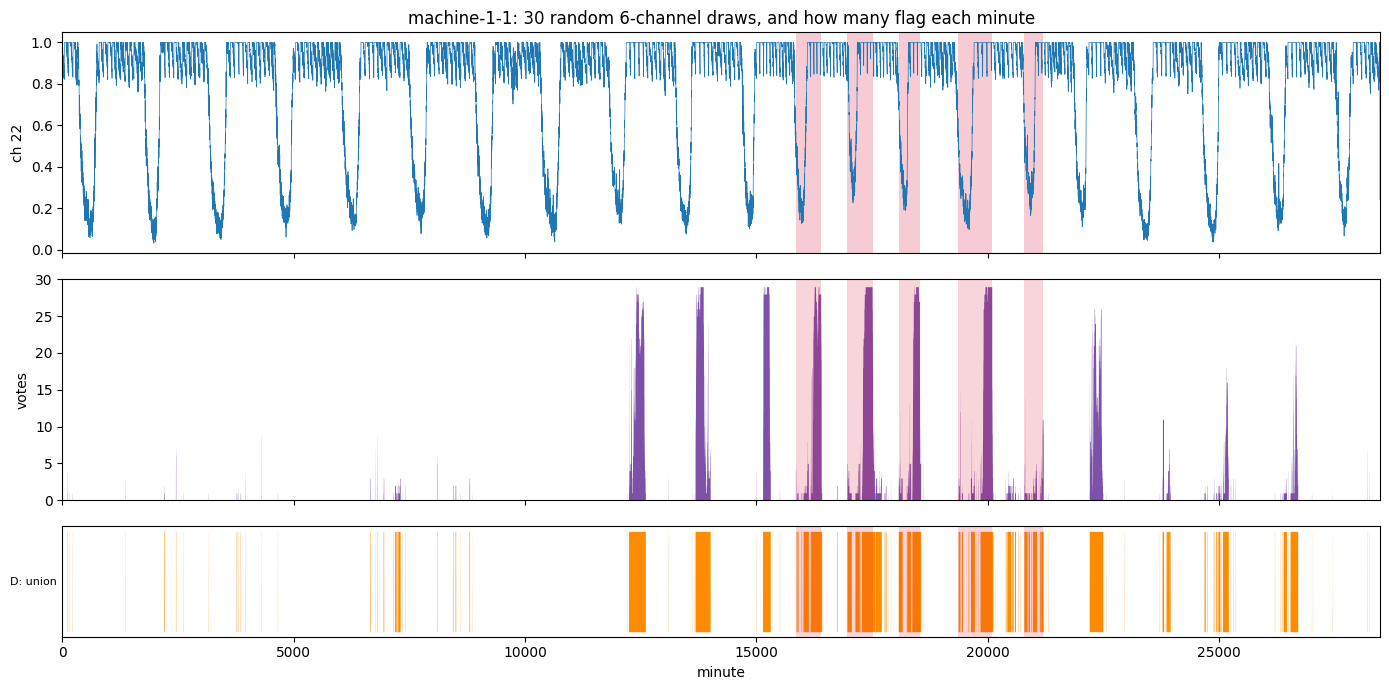

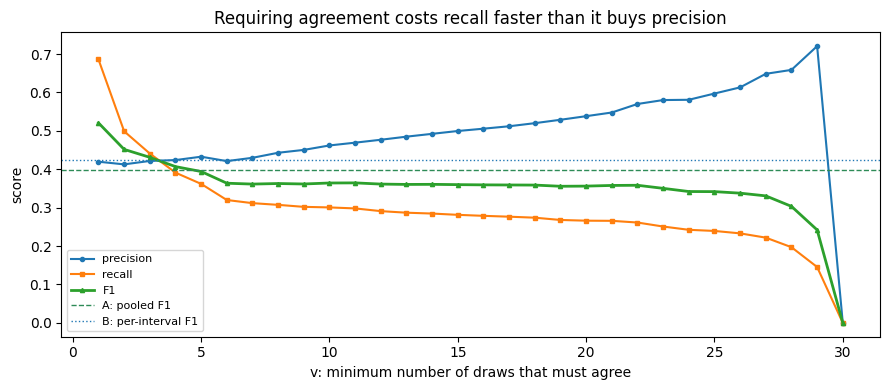

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 2, 1]})

axes[0].plot(test[busiest[0]].to_numpy(), lw=0.5, color='#1f77b4')
for lo, hi in true_segments:
    axes[0].axvspan(lo, hi, color='crimson', alpha=0.22, lw=0)
axes[0].set_ylabel('ch {0}'.format(busiest[0]))
axes[0].set_title('{0}: {1} random 6-channel draws, and how many flag each minute'
                  .format(MACHINE, R_DRAWS))

# How many draws flagged each minute - the ensemble's own confidence.
axes[1].fill_between(np.arange(len(votes)), 0, votes, color='rebeccapurple', lw=0, alpha=0.85)
for lo, hi in true_segments:
    axes[1].axvspan(lo, hi, color='crimson', alpha=0.18, lw=0)
axes[1].set_ylabel('votes')
axes[1].set_ylim(0, R_DRAWS)

axes[2].fill_between(np.arange(len(votes)), 0, (votes >= 1).astype(float),
                     color='darkorange', lw=0)
for lo, hi in true_segments:
    axes[2].axvspan(lo, hi, color='crimson', alpha=0.18, lw=0)
axes[2].set_yticks([])
axes[2].set_ylabel('D: union', fontsize=8, rotation=0, ha='right', va='center')

for ax in axes:
    ax.margins(x=0)
axes[-1].set_xlabel('minute')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(vote_curve['v'], vote_curve['precision'], 'o-', ms=3, label='precision')
ax.plot(vote_curve['v'], vote_curve['recall'], 's-', ms=3, label='recall')
ax.plot(vote_curve['v'], vote_curve['f1'], '^-', ms=3, lw=2, label='F1')
ax.axhline(result_pooled['f1'], color='seagreen', ls='--', lw=1, label='A: pooled F1')
ax.axhline(result_per_interval['f1'], color='#1f77b4', ls=':', lw=1,
           label='B: per-interval F1')
ax.set_xlabel('v: minimum number of draws that must agree')
ax.set_ylabel('score')
ax.set_title('Requiring agreement costs recall faster than it buys precision')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### The union wins, and the reason is that the draws agree

|                              | P     | R     | F1        | adj F1 | flagged |
| ---------------------------- | ----- | ----- | --------- | ------ | ------- |
| A: raw, pooled               | 0.413 | 0.383 | 0.398     | 0.785  | 8.8%    |
| B: raw, per-interval         | 0.479 | 0.379 | 0.423     | 0.828  | 7.5%    |
| C-B: UMAP-10, per-interval   | 0.700 | 0.326 | 0.444     | 0.934  | 4.4%    |
| **D: bagged x30, union**     | 0.420 | 0.686 | **0.521** | 0.678  | 15.5%   |
| flag everything              | 0.095 | 1.000 | 0.173     | 0.173  | 100%    |

**The compounding worry did not materialise, and its failure is the interesting part.** Thirty
independent detectors each flagging ~6% of points would union to about 85% of the series. The
actual union flags **15.5%**. The draws are therefore strongly correlated - they keep finding
the *same* minutes anomalous - and the independence assumption behind the worry was simply
wrong about this data.

That correlation is what makes the union safe here, and it is measurable rather than assumed:
precision is almost flat across the whole vote curve, moving from 0.420 at `v = 1` to 0.597 at
`v = 25`, while recall collapses from 0.686 to 0.239. **Demanding agreement costs recall far
faster than it buys precision**, so `v = 1` is optimal - and it is the one setting that needs
no tuning, which matters for a method meant to run without labels.

**The ensemble beats every one of its members.** Per-draw F1 has a median of 0.357 and a
maximum of 0.583, so the typical draw is *worse* than detector A's 0.398 - yet the union reaches
0.521. The draws are diverse in what they **miss** rather than in what they find: each six-channel
view catches a different part of the anomalous minutes and they agree on which minutes those
are. That is precisely the situation feature bagging exists for, and it is what section 1
predicted from the interpretation labels.

**A side effect worth noting.** Each draw's metric retains a rank between 4 and 15, against 56
for the full 38-channel corpus. Six channels give a signature space small enough to estimate
properly, so none of these draws is fitting noise directions - unlike detector C's latent
corpus, which needs 467. That is why detector C is precise but insensitive while these draws
are neither: a well-conditioned metric puts the threshold where it belongs.

### What to be careful about

`v` was chosen by looking at labels. `v = 1` needing no tuning is what rescues this - but the
*adjusted* F1 tells a different story, peaking at 0.861 around `v = 12` rather than at the
union. If the question is "did we notice each anomalous episode at all" rather than "which
minutes exactly", agreement between draws is worth demanding. The two objectives genuinely
disagree here and the operating point should follow whichever one is meant.

This is also one machine, and section 9 is unambiguous that one machine cannot order two
detectors - A and B swapped places when the sample went from four machines to 28. Detector D
beating B by 0.098 on machine-1-1 is a reason to run it across all 28, not a result.

Finally, the cost is trivial: 30 draws took about 3 minutes, roughly 6 seconds each, because six
channels give 56 signature terms at truncation 2 against 1,560 for the full set. Bagging is by
far the cheapest of the three ideas tried in this notebook, and the only one that improved on
the baseline.

## 13. Detector E: one detector per channel, aggregated

The limit of section 12's idea: instead of random subsets of six channels, take every channel
on its own. Each becomes a two-dimensional `(time, value)` series with its own corpus, its own
whitening and its own threshold, and the per-channel verdicts are combined per minute. This is
how SigNova treats its inputs - each baseline and frequency scored separately, then aggregated -
with the caveat that those are independent physical measurements while SMD's channels are
correlated telemetry from one machine.

Two details matter before the results.

**Signing `(time, value)` is what keeps this meaningful.** Section 1 noted that a 1-D path's
truncated signature collapses to `(x_T - x_0)^k / k!` - determined entirely by the net
increment, so a spike that rises and falls back is invisible. Adjoining time restores the
level-2 area between the path and its chord, so a two-dimensional path still sees shape.

**Truncation goes up to 4 here, and can.** Section 2's wall runs in reverse: two channels at
truncation 4 give 30 signature terms, against 2,374,320 for all 39. The per-channel split buys
the depth this notebook has never been able to afford anywhere else, so it would be perverse to
spend it at truncation 2. This does mean detector E differs from A in two ways at once, which
is worth remembering when reading the comparison.

**Channels that never move in training are skipped.** Their every window has an identical path,
so the signature corpus has zero variance in every direction and no metric exists to fit -
`build_whitening` would divide by zero. machine-1-1 has 8 such channels of 38.

In [37]:
%%time
TRUNC_E = 4

constant_channels = [c for c in channels if train[int(c[2:])].std() == 0]
usable_channels = [c for c in channels if c not in constant_channels]
print('{0} channels, {1} constant in training and skipped: {2}'.format(
    len(channels), len(constant_channels),
    ' '.join(c[2:] for c in constant_channels)))
print('two channels at trunc {0}: {1} signature terms (all 39 would be {2:,})'.format(
    TRUNC_E, iisignature.siglength(2, TRUNC_E), iisignature.siglength(39, TRUNC_E)))


def channel_exceedance(channel):
    """Per-minute exceedance (score / threshold) for one channel; 0 where nothing flagged.

    The search only reports intervals it flagged, so a minute no channel flagged has no score
    to contribute and is recorded as 0. `max > 1` is therefore exactly the union, and the mean
    is a mean *exceedance* rather than a mean score.
    """
    corpus_fit_e = create_corpus_merged(fit_files, trunc=TRUNC_E, granularity=GRANULARITY,
                                        time_col='time', value_cols=[channel])
    corpus_held_e = create_corpus_merged(held_files, trunc=TRUNC_E, granularity=GRANULARITY,
                                         time_col='time', value_cols=[channel])
    corpus_final_e = pd.concat([corpus_fit_e, corpus_held_e], ignore_index=True)

    sigs_e, _ = split_corpus(corpus_fit_e)
    rank_e, rcond_e = variance_rank(sigs_e)
    whitening_e = build_whitening(sigs_e, rcond=rcond_e)
    pooled_e = PooledCorpus(corpus_final_e, covariance=whitening_e, band=BAND,
                            check_scale=False)
    threshold_e = float(np.percentile(
        interval_scores(pooled_e, corpus_held_e, exclude_self=True), PERCENTILE))

    flagged_e = detect_anomalies(test_files, corpus_final_e, threshold=threshold_e,
                                 covariance=whitening_e, band=BAND, sig_tol=SIG_TOL, tol=TOL,
                                 time_col='time', value_cols=[channel])

    exceedance = np.zeros(len(labels))
    for row in flagged_e.itertuples():
        start = spec['test_offsets'][row.stream]
        span = slice(start + row.start_index, start + row.end_index + 1)
        exceedance[span] = np.maximum(exceedance[span], row.score / threshold_e)
    return exceedance, rank_e, len(flagged_e)


channel_maps, channel_rows = [], []
for channel in usable_channels:
    exceedance, rank_e, n_flagged = channel_exceedance(channel)
    channel_maps.append(exceedance)
    channel_rows.append({'channel': channel[2:], 'rank': rank_e, 'intervals': n_flagged,
                         **metrics(exceedance > 1.0, labels)})

channel_maps = np.vstack(channel_maps)
per_channel = pd.DataFrame(channel_rows)
print('\nper-channel F1: min {0:.3f}  median {1:.3f}  max {2:.3f}'.format(
    per_channel['f1'].min(), per_channel['f1'].median(), per_channel['f1'].max()))
print('per-channel metric rank: {0} to {1}'.format(
    per_channel['rank'].min(), per_channel['rank'].max()))
print('\nthe five most informative channels on their own:')
print(per_channel.nlargest(5, 'f1')[['channel', 'rank', 'intervals', 'f1', 'flagged_frac']]
      .to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))
print('\nthe noisiest, by fraction of the series flagged:')
print(per_channel.nlargest(3, 'flagged_frac')[['channel', 'intervals', 'f1', 'flagged_frac']]
      .to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

38 channels, 8 constant in training and skipped: 4 7 16 17 26 28 36 37
two channels at trunc 4: 30 signature terms (all 39 would be 2,374,320)



per-channel F1: min 0.000  median 0.290  max 0.370
per-channel metric rank: 2 to 9

the five most informative channels on their own:
channel  rank  intervals    f1  flagged_frac
     34     4         75 0.370         0.060
     35     4         75 0.370         0.060
     18     4         56 0.363         0.049
      0     5        116 0.361         0.059
     21     4         62 0.351         0.057

the noisiest, by fraction of the series flagged:
channel  intervals    f1  flagged_frac
     33       1688 0.177         0.315
      3         62 0.334         0.071
     24         54 0.348         0.069
CPU times: total: 5min 23s
Wall time: 3min 36s


In [38]:
# Three aggregations from the one set of per-channel exceedances.
agg_max = channel_maps.max(axis=0)
agg_mean = channel_maps.mean(axis=0)
agg_count = (channel_maps > 1.0).sum(axis=0)

print('-- max exceedance (a cutoff of 1.0 is exactly the union) --')
for cutoff in (1.0, 2, 5, 12, 40):
    print('  > {0:>4}: F1 {f1:.3f}  P {precision:.3f}  R {recall:.3f}  '
          'flagged {flagged_frac:5.1%}{1}'.format(
              cutoff, '   <- union' if cutoff == 1.0 else '',
              **metrics(agg_max > cutoff, labels)))

print('\n-- mean exceedance --')
for cutoff in (0.05, 0.2, 0.8, 3.0):
    print('  > {0:>4}: F1 {f1:.3f}  P {precision:.3f}  R {recall:.3f}  '
          'flagged {flagged_frac:5.1%}'.format(cutoff, **metrics(agg_mean > cutoff, labels)))

print('\n-- count of channels flagging --')
count_curve = pd.DataFrame([{'v': v, **metrics(agg_count >= v, labels)}
                            for v in range(1, len(usable_channels) + 1)])
print(count_curve[count_curve['v'] <= 8].to_string(
    index=False, float_format=lambda v: '{0:.3f}'.format(v)))

best_count = count_curve.loc[count_curve['f1'].idxmax()]
result_channelwise = metrics(agg_count >= best_count['v'], labels)
print('\nbest count rule: F1 {0:.3f} at >= {1:.0f} channels'.format(
    best_count['f1'], best_count['v']))

comparison_e = pd.DataFrame([
    {'detector': 'A: raw, pooled', **result_pooled},
    {'detector': 'B: raw, per-interval', **result_per_interval},
    {'detector': 'C-A: UMAP-10, pooled', **result_c_a},
    {'detector': 'D: bagged x{0}, union'.format(R_DRAWS), **result_bagged},
    {'detector': 'E: per-channel, union', **metrics(agg_max > 1.0, labels)},
    {'detector': 'E: per-channel, >= {0:.0f}'.format(best_count['v']), **result_channelwise},
    {'detector': 'flag everything', **result_all},
])[['detector', 'precision', 'recall', 'f1', 'adj_f1', 'flagged_frac']]
print()
print(comparison_e.to_string(index=False, float_format=lambda v: '{0:.3f}'.format(v)))

-- max exceedance (a cutoff of 1.0 is exactly the union) --
  >  1.0: F1 0.269  P 0.165  R 0.727  flagged 41.6%   <- union
  >    2: F1 0.261  P 0.161  R 0.697  flagged 41.0%
  >    5: F1 0.257  P 0.159  R 0.672  flagged 40.0%
  >   12: F1 0.249  P 0.155  R 0.632  flagged 38.5%
  >   40: F1 0.224  P 0.141  R 0.549  flagged 36.9%

-- mean exceedance --
  > 0.05: F1 0.262  P 0.161  R 0.701  flagged 41.2%
  >  0.2: F1 0.254  P 0.157  R 0.663  flagged 40.0%
  >  0.8: F1 0.229  P 0.143  R 0.573  flagged 37.8%
  >  3.0: F1 0.223  P 0.140  R 0.544  flagged 36.7%

-- count of channels flagging --
 v  precision  recall    f1  adj_recall  adj_f1  flagged_frac
 1      0.165   0.727 0.269       0.998   0.352         0.416
 2      0.352   0.471 0.403       0.997   0.696         0.127
 3      0.418   0.370 0.393       0.997   0.794         0.084
 4      0.418   0.324 0.365       0.997   0.815         0.073
 5      0.438   0.314 0.366       0.997   0.831         0.068
 6      0.443   0.305 0.361     

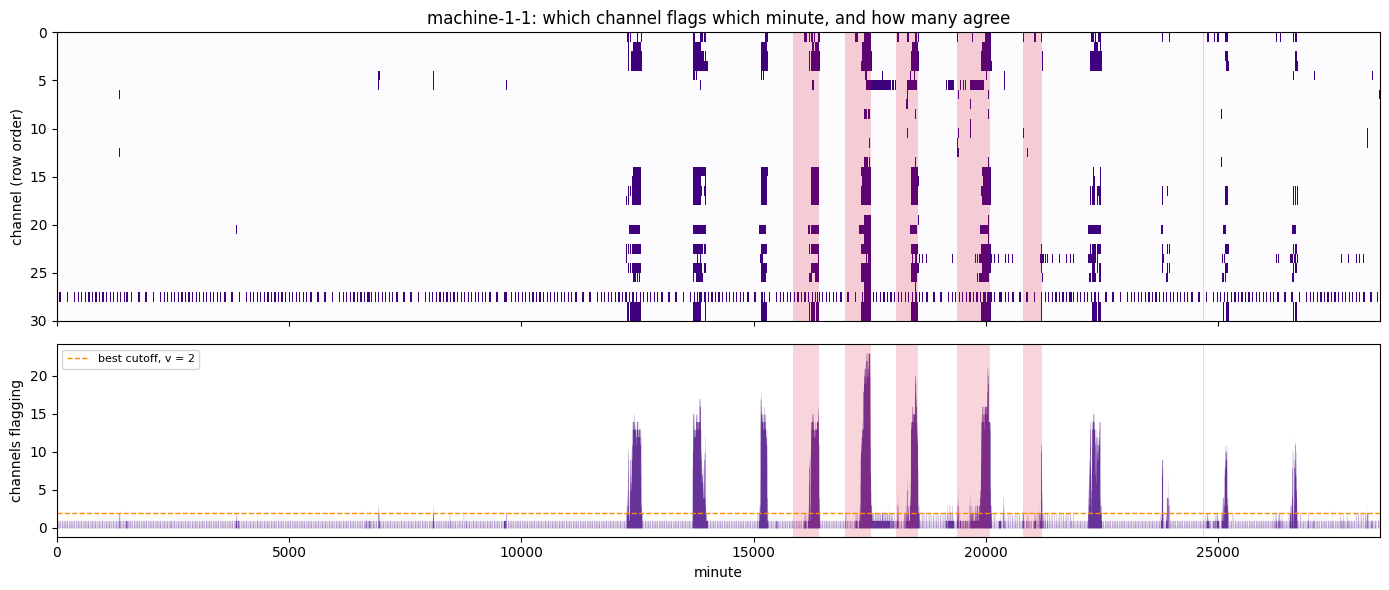

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2]})

# Which channel flagged which minute - one row per channel.
axes[0].imshow(channel_maps > 1.0, aspect='auto', cmap='Purples', interpolation='nearest',
               extent=[0, channel_maps.shape[1], len(usable_channels), 0])
for lo, hi in true_segments:
    axes[0].axvspan(lo, hi, color='crimson', alpha=0.20, lw=0)
axes[0].set_ylabel('channel (row order)')
axes[0].set_title('{0}: which channel flags which minute, and how many agree'.format(MACHINE))

axes[1].fill_between(np.arange(len(agg_count)), 0, agg_count, color='rebeccapurple', lw=0)
for lo, hi in true_segments:
    axes[1].axvspan(lo, hi, color='crimson', alpha=0.18, lw=0)
axes[1].axhline(best_count['v'], color='darkorange', ls='--', lw=1,
                label='best cutoff, v = {0:.0f}'.format(best_count['v']))
axes[1].set_ylabel('channels flagging')
axes[1].set_xlabel('minute')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.margins(x=0)
plt.tight_layout(); plt.show()

### The union collapses here, and one channel is why

| rule                            | P     | R     | F1        | flagged   |
| ------------------------------- | ----- | ----- | --------- | --------- |
| max > 1 (the union)             | 0.165 | 0.727 | 0.269     | **41.6%** |
| mean exceedance, best cutoff    | 0.161 | 0.701 | 0.262     | 41.2%     |
| **count >= 2**                  | 0.352 | 0.471 | **0.403** | 12.7%     |
| count >= 3                      | 0.418 | 0.370 | 0.393     | 8.4%      |

Section 12's union flagged 15.5% of the series and won; this one flags **41.6%** and does not.
The difference is a single channel. **`ch33` alone flags 31.5% of the test period** - 1,688
intervals - and standing on its own it floods the union directly. In detector D a badly-behaved
channel was one of six inside a draw, and the draw's own metric and threshold absorbed it; here
each channel is its own detector and nothing dilutes it.

Raising the cutoff does not rescue the max rule: F1 falls from 0.269 to 0.224 as the cutoff
goes from 1 to 40, because `ch33`'s flagging persists at every magnitude. The severity
information is real but it is not the axis that separates this channel from the useful ones.
Requiring two channels to agree removes it at a stroke, which is why `count >= 2` is the best
rule available here - and it lands at 0.403, barely past detector A's 0.398 and below B's 0.423.

### Why detector D beats detector E

**Cross-channel terms.** A single `(time, value)` path has exactly one level-2 term, the area
against time; it has no term mixing two *value* channels, because it has only one. A
six-channel draw carries fifteen such cross terms, so it can see an anomaly in the
*relationship* between channels - two counters that normally move together drifting apart - and
a per-channel detector structurally cannot. The retained ranks say the same thing more bluntly:
2 to 6 per channel here, against 4 to 15 per draw in section 12.

That is a real argument for subsets over singletons, and it is not an argument about
dimensionality at all. Truncation 4 gave detector E strictly more path detail per channel than
detector D had at truncation 2, and it still lost - so what D has that E lacks is not depth but
the cross terms.

### The finding worth keeping

**A single channel nearly matches all 38.** Median per-channel F1 is 0.290, and channels 34, 35,
18, 0 and 21 reach 0.35-0.37 on their own, against 0.398 for the full 38-channel detector. One
counter out of thirty-eight, signed against time, recovers most of what the whole machine's
telemetry does.

That is the strongest evidence in this notebook for section 1's dilution argument, and it points
somewhere none of sections 11 to 13 went: **channel selection**. If five channels carry nearly
all the signal, the useful question is which five and how to find them without labels - not how
to compress thirty-eight into ten, nor how to sample six at random. Detector D's per-draw table
is the natural place to start, since draws containing channels 0, 18, 34 and 35 are exactly the
ones that scored best.

## 14. What this means for the pipeline

**1. `calibrate_threshold` is unsound as written, and it is what the Snakefile calls.** It
derives the threshold from the corpus's own nearest-neighbour distances, which understate
what unseen normal data scores by an order of magnitude - so the threshold lands below the
median of normal-but-unseen intervals and the detector flags almost everything. It must take
a withheld normal set instead.

**2. The `split` rule needs a third way.** The workflow splits into base and test. It needs
fit / withheld / test, with the withheld portion feeding calibration and then joining the
reference set. Without it, fix 1 has nowhere to get its data. This is a small change to the
Snakefile and `config.yaml`.

**3. Calibration must be measured against the reference set that will actually be searched.**
This is the new finding here. Folding the withheld windows back in - which is worth doing,
since coverage of normality is what a nearest-neighbour detector is short of - shifts every
score downward, by a factor of 1.6x to 4.7x across the sensitivity grid. Scoring the withheld
intervals against the final index with their own self-match excluded costs nothing and puts
the threshold on the right scale. A `calibrate` rule that takes both the withheld windows and
the final corpus, rather than just a corpus, is the shape this wants.

**4. `build_whitening`'s `rcond=1e-12` default is far too permissive in high dimensions.** It
keeps all 992 directions where a few dozen carry 99.9% of the variance, and the discarded
ones are pure sampling noise that the whitening then divides by. A retained-variance rule
adapts to the corpus where a constant cannot. But section 10 shows the retention level is
itself consequential and cannot be chosen without labels, so this replaces a bad default with
an honest hyperparameter rather than solving the problem.

**5. The module's search internals should be public.** Detector B needed
`widest_first_segment` (already public) and `_invert` (not), plus its own characteristic
function. That is exactly the extension point the SigNova search is worth having - the search
is independent of what "clean" means - and it is currently only reachable by importing a
private name. Promoting `_invert`, and factoring `detect_stream_anomalies` so the
characteristic function is an argument, would make detector B a caller rather than a
reimplementation.

**6. `PooledCorpus` needs a batched `score_many`, and it should be hard to use wrongly.**
Every diagnostic here reached into `pooled._index`, and the k=1/k=2 self-match distinction is
exactly the kind of trap a public method should absorb: scoring intervals that are themselves
in the index must skip the self-match, and an API that leaves that to the caller will keep
producing medians of 0.0.

**7. The per-interval reference is affordable and belongs in the package.** The obstacle
looks like cost - a fresh corpus and a fresh metric per candidate interval - and it is not,
because the reference at `[lo, hi]` depends only on the interval, so memoisation collapses
the work to the number of distinct intervals the search visits, which is small. Storing the
metric as a rank-`r` projection rather than a `D x D` matrix is what makes caching them
practical.

**8. Nothing global transfers between machines - not the threshold, and not the rank rule.**
Across 28 machines the retained-variance rule alone selected ranks from 29 to 275 (median
93), and AUC ranged from 0.582 to 0.984. Two failure modes need telling apart, and only the
AUC distinguishes them: on machine-2-2 the AUC is 0.692 while point-wise F1 is 0.116, so the
scores are usable and the threshold is misplaced; on machine-3-2 the AUC is 0.582 and no
threshold would have helped. That is a concrete argument for `evaluate` reporting AUC beside
F1, since the two failures call for opposite responses. Section 1's test-period figure adds a
caveat to the machine-3-2 reading, though: its largest visible regime change is unlabelled,
so some of that lost AUC may be the detector finding real structure the labels do not mark. Whatever replaces
`calibrate_threshold` must be fitted per stream group, which the workflow already supports
structurally since `THRESHOLD` is wildcarded by dataset.

**9. Detector B earns a place in the package, on the evidence of all 28 machines.** It leads
on mean point-wise F1, median point-wise F1 and mean adjusted F1, and wins on 17 machines to
A's 10. The reason is calibration rather than representation: per-interval thresholds bring
the median flagged fraction to 1.6x the true anomaly rate against A's 3.6x. It costs about 90
seconds per machine against A's 20, which memoisation turns into a constant factor rather
than a barrier. It should not silently become the default, though: it still loses on 10
machines, and there is no label-free way to tell in advance which kind of machine you have.

**10. `scoring.py` should become section 4.** The `evaluate` rule is a placeholder only
because there was nothing to score against; the point-wise and point-adjusted metrics here
are what it needs, and the flagged-fraction column beside them is what keeps point-adjust
honest.

### Things worth trying next

- **A calibration target that is not a percentile of normal.** Everything here sets the
  threshold from the normal distribution alone, and section 9 shows that is not enough. Using
  the *shape* of the test score distribution - a two-component mixture, or the largest gap in
  the sorted scores - would adapt per machine without needing labels, and would attack the
  section 10 problem directly.
- **Per-depth thresholds for detector A**, each calibrated from the withheld set at that
  depth. Detector B already has this implicitly, since every interval carries its own
  threshold; the comparison would isolate how much of B's behaviour comes from the per-scale
  metric versus the per-scale threshold.
- **Non-overlapping fit windows.** The 50% stride makes corpus intervals strongly correlated,
  which inflates in-sample optimism. Worth measuring rather than assuming.
- **Level 3 on a reduced channel set.** A label-free variance ranking down to 8 channels makes
  width 9 and `trunc=3` (819 terms) affordable, buying back the third-order structure section
  2 gave up. Detector B benefits most, since its per-interval corpora are the rank-starved
  ones.
- **All 28 machines**, for a number comparable with the published SMD literature rather than
  a four-machine sample.